# Comprehensive Pandas — Data Exploration and Preprocessing
## An Independent, Step-by-Step Study Notebook
Pandas is the main Python library we use for **tabular data**: rows of observations and columns of variables.  
Pandas becomes the bridge between raw tabular data and later analytical or machine-learning tasks such as regression, classification, clustering, and exploratory analysis.

### Our learning story

We will act as data analysts for a small retail company. We have received a transaction table, but we do **not** yet know whether it is reliable.

Our job is to move through the following reasoning chain:

**Understand the pandas objects → build the raw table → inspect it → select data → filter data → clean problems → create useful variables → summarize patterns → reshape/combine tables → visualize → export → prepare features and a target.**

The important rule throughout this notebook is:

> **We do not clean, transform, or model data before we understand what is actually in the table.**

Each code cell has **one main task**. Run the notebook slowly and read the explanation before moving to the next cell.

## Learning outcomes

By the end of this notebook, we should be able to:

1. Explain the difference between a pandas `Series` and `DataFrame`.
2. Understand labels, indexes, columns, and data types.
3. Inspect a dataset systematically before analysis.
4. Select rows and columns using `[]`, `.loc`, `.iloc`, `.at`, and `.iat`.
5. Filter observations using one or more conditions.
6. Sort, rank, and search tabular data.
7. Detect and handle missing values, duplicates, and inconsistent categories.
8. Work safely with text and date columns.
9. Create calculated and categorical features.
10. Detect possible outliers without automatically deleting them.
11. Summarize data with `value_counts`, `groupby`, aggregation, and `transform`.
12. Build cross-tabulations and pivot tables.
13. Reshape data with `melt` and `explode`.
14. Combine tables with `merge` and `concat`.
15. Calculate correlations and create basic pandas plots.
16. Encode categorical variables and prepare `X` and `y` for later machine-learning work.
17. Read and write CSV data with useful `read_csv` options.
18. Use method chaining, validation checks, and basic memory-aware practices.

## Road map

### Core sequence
1. Pandas mental model
2. `Series`
3. `DataFrame`
4. Build our retail dataset
5. Inspect before cleaning
6. Select rows and columns
7. Filter, sort, and rank
8. Create a safe working copy
9. Missing values
10. Text inconsistencies and duplicates
11. Data types
12. Calculated columns
13. Outlier investigation
14. Dates and time-aware analysis
15. Frequencies and `groupby`
16. Cross-tabulations and pivot tables
17. Reshaping
18. Combining tables
19. Correlation and visualization
20. Encoding and ML preparation
21. CSV input/output

### Teaching extensions
22. Index management
23. Method chaining
24. Validation checks
25. Window calculations
26. Memory awareness and chunking
27. Common mistakes
28. Exercises and solutions

## Official pandas documentation used to extend this notebook

This teaching sequence was expanded using the **official pandas documentation**, especially the stable User Guide sections on:

- 10 minutes to pandas
- indexing and selecting data
- missing data
- text data
- merge / join / concatenate
- groupby: split-apply-combine
- reshaping and pivot tables
- categorical data
- time series
- input/output tools
- scaling to larger datasets

Reference links are collected again at the end of the notebook.

## 1. Set up the environment

Before learning pandas operations, we first load the libraries used throughout the notebook.

### 1.1 Import the libraries

We import pandas as `pd`, NumPy as `np`, and Matplotlib for a few visualizations. These short aliases are conventional and make later code easier to read.

In [1]:
# pandas provides Series/DataFrame and most tabular-data operations.
import pandas as pd

# NumPy provides numerical tools and the np.nan missing-value marker used in our raw data.
import numpy as np

# Matplotlib is used by pandas plotting methods to display charts.
import matplotlib.pyplot as plt

### 1.2 Check the pandas version

Pandas evolves over time. Recording the version helps us explain small differences that students may see on different computers.

In [2]:
# Display the installed pandas version for reproducibility.
print("Pandas version:", pd.__version__)

Pandas version: 2.2.3


## 2. First mental model: a `Series`

A `Series` is a **one-dimensional labeled collection**. Think of it as one meaningful column plus an index that identifies each value.

### 2.1 Create a simple Series

We begin with weekly sales because the data has a natural label for every value. Notice that the labels are not stored as a separate column; they form the Series index.

In [3]:
# Create one labeled sequence of weekly sales values.
sales_series = pd.Series(
    [1200, 1500, 900, 1800],
    index=["Week 1", "Week 2", "Week 3", "Week 4"],
    name="Sales"
)

sales_series

Week 1    1200
Week 2    1500
Week 3     900
Week 4    1800
Name: Sales, dtype: int64

### 2.2 Inspect the Series index

Before selecting values, we should notice that a Series contains both **data values** and **labels**. The `index` stores those labels.

In [4]:
# Show the labels attached to the four sales values.
sales_series.index

Index(['Week 1', 'Week 2', 'Week 3', 'Week 4'], dtype='object')

### 2.3 Inspect the Series data type

Pandas stores a data type (`dtype`) for the values. Data types matter because they determine which operations are valid and how much memory is used.

In [5]:
# Check the type used to store the sales values.
sales_series.dtype

dtype('int64')

### 2.4 Select one value by label

Because the Series is labeled, we can request a value using its business meaning (`Week 2`) instead of remembering its physical position.

In [6]:
# Select the sales value whose label is "Week 2".
sales_series.loc["Week 2"]

np.int64(1500)

### 2.5 Perform vectorized arithmetic

A major advantage of pandas is **vectorization**. We can transform the whole Series in one statement instead of writing a loop for every row.

In [7]:
# Increase every weekly sales value by 10%.
sales_with_growth = sales_series * 1.10

sales_with_growth

Week 1    1320.0
Week 2    1650.0
Week 3     990.0
Week 4    1980.0
Name: Sales, dtype: float64

### 2.6 Why labels matter: automatic alignment

Pandas arithmetic is often **label-aware**, not merely position-aware.

This is a powerful idea. If two Series have the same labels in a different order, pandas can align values using the labels before performing arithmetic.

> **Predict first:** Will the first value of `price` simply subtract the first value of `discount`, or will pandas match `"A"` with `"A"`?

In [8]:
# Create prices in A-B order.
price = pd.Series([100, 200], index=["A", "B"])

# Create discounts deliberately in B-A order.
discount = pd.Series([20, 10], index=["B", "A"])

# pandas aligns labels before subtraction.
price - discount

A     90
B    180
dtype: int64

## 3. From one Series to a `DataFrame`

Real datasets contain several variables at the same time. A `DataFrame` is a **two-dimensional labeled table** made of rows and columns.

We now move from one labeled sequence to a small student table so that we can see how columns coexist.

### 3.1 Create a small DataFrame

Each dictionary key becomes a column name. Each list supplies the values for that column.

In [9]:
# Build a small table from a Python dictionary of equally sized lists.
students = pd.DataFrame({
    "Name": ["Ali", "Sara", "Omar", "Noura"],
    "Age": [21, 22, 20, 23],
    "Mark": [78, 92, 65, 88]
})

students

,Name,Age,Mark
0,Ali,21,78
1,Sara,22,92
2,Omar,20,65
3,Noura,23,88


### 3.2 Check the DataFrame shape

`shape` returns `(number_of_rows, number_of_columns)`. This is one of the first checks we should perform on any dataset.

In [10]:
# Count rows and columns without manually inspecting the table.
students.shape

(4, 3)

### 3.3 Inspect column labels

Column names are labels. Good column labels make later selection and analysis much easier to read.

In [11]:
# Display the column labels in their current order.
students.columns

Index(['Name', 'Age', 'Mark'], dtype='object')

### 3.4 Inspect row labels

The left-most numbers shown in a DataFrame are the **index**, not an ordinary data column. By default pandas creates a `RangeIndex` beginning at 0.

In [12]:
# Display the row index used to identify observations.
students.index

RangeIndex(start=0, stop=4, step=1)

### 3.5 Inspect data types by column

A DataFrame can hold different data types in different columns. Here, text and numeric columns coexist in the same table.

In [13]:
# Show the dtype pandas inferred for every column.
students.dtypes

Name    object
Age      int64
Mark     int64
dtype: object

## 4. Build the retail practice dataset

Now that we understand the two core pandas objects, we can build the dataset that will support the rest of the tutorial.

The table deliberately contains realistic data-quality problems:

- a missing customer age,
- a missing city,
- the text value `"Unknown"` in Gender,
- a duplicated transaction,
- an unusually large quantity (`50`),
- a date stored initially as text.

We will **not fix any of these yet**. First we preserve the raw evidence.

### 4.1 Define the raw data

We first store the columns in a Python dictionary. Keeping this step separate from DataFrame creation helps us distinguish ordinary Python structures from pandas structures.

In [14]:
# Each key is a future column and each list contains that column's raw values.
data = {
    "Transaction_ID": ["T001","T002","T003","T004","T005","T006","T007","T008","T009","T010","T010"],
    "Customer_Age": [22,35,28,45,31,52,24,np.nan,39,27,27],
    "Gender": ["Female","Male","Female","Male","Female","Male","Female","Unknown","Male","Female","Female"],
    "City": ["Jeddah","Riyadh","Jeddah","Dammam","Makkah","Jeddah","Riyadh","Makkah",np.nan,"Jeddah","Jeddah"],
    "Category": ["Beverages","Electronics","Bakery","Household","Dairy","Electronics","Snacks","Produce","Personal Care","Bakery","Bakery"],
    "Quantity": [2,1,3,4,2,1,5,2,50,3,3],
    "Unit_Price": [8.5,250.0,12.0,35.0,18.0,320.0,6.0,10.0,25.0,15.0,15.0],
    "Discount_Percent": [0,10,5,0,15,5,0,0,20,10,10],
    "Purchase_Date": ["2026-06-01","2026-06-01","2026-06-02","2026-06-03","2026-06-03","2026-06-04","2026-06-05","2026-06-05","2026-06-06","2026-06-07","2026-06-07"],
    "Returned": ["No","Yes","No","No","No","Yes","No","No","No","No","No"]
}

### 4.2 Convert the dictionary to a DataFrame

The data becomes analytically useful once pandas organizes it into a labeled table.

In [15]:
# Convert the raw Python dictionary into a pandas DataFrame.
retail_raw = pd.DataFrame(data)

retail_raw

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
0,T001,22.0,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No
3,T004,45.0,Male,Dammam,Household,4,35.0,0,2026-06-03,No
4,T005,31.0,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No
5,T006,52.0,Male,Jeddah,Electronics,1,320.0,5,2026-06-04,Yes
6,T007,24.0,Female,Riyadh,Snacks,5,6.0,0,2026-06-05,No
7,T008,NaN,Unknown,Makkah,Produce,2,10.0,0,2026-06-05,No
8,T009,39.0,Male,NaN,Personal Care,50,25.0,20,2026-06-06,No
9,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No


### 4.3 Preserve the raw table

A good analysis workflow keeps the untouched source available. Later, we will clean a separate working copy instead of destroying our original evidence.

In [16]:
# Create an explicit backup that we will not modify during cleaning.
raw_backup = retail_raw.copy()

print("Raw backup created with shape:", raw_backup.shape)

Raw backup created with shape: (11, 10)


## 5. Inspect before cleaning

We now know that the table exists, but we still do not know enough to clean it responsibly.

A systematic first inspection asks:

1. How large is the table?
2. What are the column names?
3. What kinds of values are stored?
4. Which columns are numeric or text?
5. Are values missing?
6. Are rows duplicated?
7. What do basic distributions look like?

We answer these questions **before** changing the data.

### 5.1 Preview the first rows with `head()`

A small preview helps us connect column names with actual values without printing the entire dataset.

In [17]:
# Display the first five observations.
retail_raw.head()

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
0,T001,22.0,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No
3,T004,45.0,Male,Dammam,Household,4,35.0,0,2026-06-03,No
4,T005,31.0,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No


### 5.2 Preview the last rows with `tail()`

The end of a file can reveal repeated rows, footer-like records, or patterns that the first rows do not show.

In [18]:
# Display the final five observations.
retail_raw.tail()

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
6,T007,24.0,Female,Riyadh,Snacks,5,6.0,0,2026-06-05,No
7,T008,NaN,Unknown,Makkah,Produce,2,10.0,0,2026-06-05,No
8,T009,39.0,Male,NaN,Personal Care,50,25.0,20,2026-06-06,No
9,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No
10,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No


### 5.3 Inspect a random sample

The first and last rows are position-dependent. `sample()` gives us observations from different parts of a larger dataset. We use `random_state` so the teaching output is reproducible.

In [19]:
# Randomly inspect three rows in a reproducible way.
retail_raw.sample(n=3, random_state=42)

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
5,T006,52.0,Male,Jeddah,Electronics,1,320.0,5,2026-06-04,Yes
0,T001,22.0,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No
9,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No


### 5.4 Check the shape

Before cleaning, the shape gives us a baseline. If rows disappear later, we will know how many were removed.

In [20]:
# Store row and column counts in separate variables for clear interpretation.
n_rows, n_columns = retail_raw.shape

print("Rows:", n_rows)
print("Columns:", n_columns)

Rows: 11
Columns: 10


### 5.5 Inspect column names

Column labels determine how we will select and transform variables. Listing them early prevents spelling mistakes later.

In [21]:
# Convert the Index of column labels to a simple Python list for easy reading.
retail_raw.columns.tolist()

['Transaction_ID',
 'Customer_Age',
 'Gender',
 'City',
 'Category',
 'Quantity',
 'Unit_Price',
 'Discount_Percent',
 'Purchase_Date',
 'Returned']

### 5.6 Inspect data types

Data types are not just technical details. A date stored as text cannot yet support date arithmetic, and a number stored as text cannot be summarized numerically.

In [22]:
# Show pandas' current dtype inference for every variable.
retail_raw.dtypes

Transaction_ID       object
Customer_Age        float64
Gender               object
City                 object
Category             object
Quantity              int64
Unit_Price          float64
Discount_Percent      int64
Purchase_Date        object
Returned             object
dtype: object

### 5.7 Use `info()` for a structural summary

`info()` combines column names, non-null counts, dtypes, and memory information. It is one of the fastest ways to detect structural problems.

In [23]:
# Print a concise structural report of the DataFrame.
retail_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    11 non-null     object 
 1   Customer_Age      10 non-null     float64
 2   Gender            11 non-null     object 
 3   City              10 non-null     object 
 4   Category          11 non-null     object 
 5   Quantity          11 non-null     int64  
 6   Unit_Price        11 non-null     float64
 7   Discount_Percent  11 non-null     int64  
 8   Purchase_Date     11 non-null     object 
 9   Returned          11 non-null     object 
dtypes: float64(2), int64(2), object(6)
memory usage: 1012.0+ bytes


### 5.8 Summarize numerical variables

`describe()` on numeric columns gives count, mean, standard deviation, minimum, quartiles, and maximum. Large gaps between quartiles and maxima can suggest unusual values.

In [24]:
# Summarize only columns pandas currently recognizes as numeric.
retail_raw.describe()

,Customer_Age,Quantity,Unit_Price,Discount_Percent
count,10.000000,11.000000,11.000000,11.000000
mean,33.000000,6.909091,64.954545,6.818182
std,9.706813,14.341928,110.211718,6.809085
min,22.000000,1.000000,6.000000,0.000000
25%,27.000000,2.000000,11.000000,0.000000
50%,29.500000,3.000000,15.000000,5.000000
75%,38.000000,3.500000,30.000000,10.000000
max,52.000000,50.000000,320.000000,20.000000


### 5.9 Summarize non-numerical variables

Text columns need different summaries. For them, `describe()` reports counts, unique values, the most frequent value, and its frequency.

In [25]:
# Summarize object/string-like columns separately from numeric variables.
retail_raw.describe(include=["object"])

,Transaction_ID,Gender,City,Category,Purchase_Date,Returned
count,11,11,10,11,11,11
unique,10,3,4,8,7,2
top,T010,Female,Jeddah,Bakery,2026-06-01,No
freq,2,6,5,3,2,9


### 5.10 Count missing values

A missing-value count tells us **where** information is absent. We should detect missingness before deciding whether to fill or remove anything.

In [26]:
# Count NA values in each column.
retail_raw.isna().sum()

Transaction_ID      0
Customer_Age        1
Gender              0
City                1
Category            0
Quantity            0
Unit_Price          0
Discount_Percent    0
Purchase_Date       0
Returned            0
dtype: int64

### 5.11 Measure missing-value percentages

Counts alone can be misleading when datasets have very different sizes. Percentages give the missingness relative to the number of rows.

In [27]:
# Convert missing-value counts to percentages of all rows.
missing_percent = retail_raw.isna().mean() * 100

missing_percent.round(2)

Transaction_ID      0.00
Customer_Age        9.09
Gender              0.00
City                9.09
Category            0.00
Quantity            0.00
Unit_Price          0.00
Discount_Percent    0.00
Purchase_Date       0.00
Returned            0.00
dtype: float64

### 5.12 Count duplicated rows

Duplicate records can overrepresent events. We first count them; we do not delete them until we verify what they are.

In [28]:
# Count rows that are exact duplicates of an earlier row.
retail_raw.duplicated().sum()

np.int64(1)

### 5.13 Count unique values in every column

Missing values and duplicates tell us about data quality, but we also need to understand **cardinality**: how many distinct values each variable contains.

`nunique()` is especially useful for identifying:
- identifier-like columns with many unique values,
- binary variables with two values,
- categorical variables with a small vocabulary.

In [29]:
# Count distinct non-missing values in each column.
retail_raw.nunique()

Transaction_ID      10
Customer_Age         9
Gender               3
City                 4
Category             8
Quantity             6
Unit_Price          10
Discount_Percent     5
Purchase_Date        7
Returned             2
dtype: int64

### 5.14 Inspect the actual Category labels

A count tells us *how many* categories exist; `unique()` shows *which labels* are present.

This distinction matters because inconsistent labels such as `"Electronics"` and `"electronics"` would count as two different categories.

In [30]:
# Display the distinct product-category labels in their observed order.
retail_raw["Category"].unique()

array(['Beverages', 'Electronics', 'Bakery', 'Household', 'Dairy',
       'Snacks', 'Produce', 'Personal Care'], dtype=object)

## 6. Selecting columns and rows

Inspection told us what exists. The next skill is **subsetting**: asking pandas for only the part of the table needed for a question.

We will learn five related access patterns:

- `df["Column"]` → one column
- `df[["A", "B"]]` → several columns
- `.loc[...]` → label/condition based selection
- `.iloc[...]` → integer-position based selection
- `.at` / `.iat` → one scalar value

The distinction between labels and positions is fundamental.

### 6.1 Select one column

Selecting a single column with one pair of brackets returns a `Series`, not a DataFrame.

In [31]:
# Select the Category variable as a Series.
category_series = retail_raw["Category"]

category_series.head()

0      Beverages
1    Electronics
2         Bakery
3      Household
4          Dairy
Name: Category, dtype: object

### 6.2 Confirm the returned object type

Seeing the object type makes the single-bracket behavior explicit.

In [32]:
# Verify that one selected column is a Series.
type(category_series)

pandas.core.series.Series

### 6.3 Select several columns

Passing a list of column labels returns a new DataFrame because the result is still two-dimensional.

In [33]:
# Keep only three variables relevant to a simple transaction view.
retail_raw[["Category", "Quantity", "Unit_Price"]].head()

,Category,Quantity,Unit_Price
0,Beverages,2,8.5
1,Electronics,1,250.0
2,Bakery,3,12.0
3,Household,4,35.0
4,Dairy,2,18.0


### 6.4 Select rows by integer position with `.iloc`

`.iloc` means **integer location**. It is useful when we know physical row positions rather than row labels.

In [34]:
# Select the first three rows by position.
retail_raw.iloc[:3]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
0,T001,22.0,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No


### 6.5 Select rows and columns by integer position

Both axes can be sliced with `.iloc`. Here, rows 0–2 and columns 0–2 are selected by position.

In [35]:
# Select the first three rows and first three columns.
retail_raw.iloc[:3, :3]

,Transaction_ID,Customer_Age,Gender
0,T001,22.0,Female
1,T002,35.0,Male
2,T003,28.0,Female


### 6.6 Select by labels with `.loc`

`.loc` is label-based. With a default integer index, row labels happen to look like positions, but conceptually they are still labels.

A useful detail from the pandas indexing rules:

> Label slices with `.loc` include the **ending label**, unlike ordinary Python positional slices.

In [36]:
# Select row labels 0 through 2 and three named columns.
retail_raw.loc[0:2, ["Transaction_ID", "Category", "Quantity"]]

,Transaction_ID,Category,Quantity
0,T001,Beverages,2
1,T002,Electronics,1
2,T003,Bakery,3


### 6.7 Select one scalar with `.at`

When we need exactly one value by row and column labels, `.at` expresses that intention directly.

In [37]:
# Read the Category value at row label 0.
retail_raw.at[0, "Category"]

'Beverages'

### 6.8 Select one scalar with `.iat`

`.iat` performs scalar access by integer position instead of labels.

In [38]:
# Read the value at row position 0 and column position 4.
retail_raw.iat[0, 4]

'Beverages'

### 6.9 Select columns by data type

As datasets grow, manually listing every numeric column becomes inconvenient. `select_dtypes()` lets the schema itself guide selection.

In [39]:
# Automatically collect all currently numeric columns.
numeric_raw = retail_raw.select_dtypes(include="number")

numeric_raw.head()

,Customer_Age,Quantity,Unit_Price,Discount_Percent
0,22.0,2,8.5,0
1,35.0,1,250.0,10
2,28.0,3,12.0,5
3,45.0,4,35.0,0
4,31.0,2,18.0,15


### 6.10 Rename a column without changing the original table

Column names are part of the dataset schema. `rename()` is useful when incoming names are unclear, inconsistent, or inconvenient.

We demonstrate it on a temporary DataFrame so the rest of the notebook can continue using the original column name.

In [40]:
# Create a renamed preview; retail_raw itself remains unchanged.
renamed_preview = retail_raw.rename(
    columns={"Unit_Price": "UnitPrice"}
)

renamed_preview.columns.tolist()

['Transaction_ID',
 'Customer_Age',
 'Gender',
 'City',
 'Category',
 'Quantity',
 'UnitPrice',
 'Discount_Percent',
 'Purchase_Date',
 'Returned']

### 6.11 Drop an unnecessary column without changing the original table

`drop()` removes selected rows or columns from the returned result.

Because our later analysis still needs `Returned`, we demonstrate the method on a temporary preview rather than permanently deleting the variable.

In [41]:
# Create a temporary view without the Returned column.
without_returned = retail_raw.drop(
    columns=["Returned"]
)

without_returned.head()

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date
0,T001,22.0,Female,Jeddah,Beverages,2,8.5,0,2026-06-01
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02
3,T004,45.0,Male,Dammam,Household,4,35.0,0,2026-06-03
4,T005,31.0,Female,Makkah,Dairy,2,18.0,15,2026-06-03


## 7. Filtering observations

Selection answers **which columns or positions?**  
Filtering answers **which rows satisfy a condition?**

Pandas creates a Boolean Series (`True` / `False`) for a condition, then uses that Series as a row mask.

We will build this idea gradually before combining conditions.

### 7.1 Build a Boolean condition

Before filtering, it is useful to see the Boolean mask itself. Every row receives `True` if its category is Electronics and `False` otherwise.

In [42]:
# Compare every Category value with the target label.
is_electronics = retail_raw["Category"] == "Electronics"

is_electronics

0     False
1      True
2     False
3     False
4     False
5      True
6     False
7     False
8     False
9     False
10    False
Name: Category, dtype: bool

### 7.2 Apply the Boolean mask

Once the mask makes sense, we use it inside brackets to keep only rows where the condition is `True`.

In [43]:
# Keep only Electronics transactions.
retail_raw[is_electronics]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
5,T006,52.0,Male,Jeddah,Electronics,1,320.0,5,2026-06-04,Yes


### 7.3 Combine two conditions

For element-wise pandas conditions we use `&` for AND and place each comparison in parentheses. Python's ordinary `and` does not operate row by row on a Series.

In [44]:
# Require both Electronics category AND a returned transaction.
electronics_returned = (
    (retail_raw["Category"] == "Electronics")
    & (retail_raw["Returned"] == "Yes")
)

retail_raw[electronics_returned]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
5,T006,52.0,Male,Jeddah,Electronics,1,320.0,5,2026-06-04,Yes


### 7.4 Filter with `.isin()`

When one column may match several accepted values, `.isin()` is clearer than writing many OR conditions.

In [45]:
# Keep transactions belonging to either Electronics or Bakery.
retail_raw[retail_raw["Category"].isin(["Electronics", "Bakery"])]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No
5,T006,52.0,Male,Jeddah,Electronics,1,320.0,5,2026-06-04,Yes
9,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No
10,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No


### 7.5 Filter a numeric interval with `.between()`

Range questions are common: ages, prices, dates, and scores. `.between()` expresses lower and upper bounds clearly.

In [46]:
# Keep customers whose known age lies between 25 and 40, inclusive.
retail_raw[retail_raw["Customer_Age"].between(25, 40)]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No
4,T005,31.0,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No
8,T009,39.0,Male,NaN,Personal Care,50,25.0,20,2026-06-06,No
9,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No
10,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No


### 7.6 Keep rows where a value is present

`notna()` is the natural opposite of `isna()`. It is useful when an operation requires complete values in a specific column.

In [47]:
# Keep only observations with a known City.
retail_raw[retail_raw["City"].notna()]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
0,T001,22.0,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No
3,T004,45.0,Male,Dammam,Household,4,35.0,0,2026-06-03,No
4,T005,31.0,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No
5,T006,52.0,Male,Jeddah,Electronics,1,320.0,5,2026-06-04,Yes
6,T007,24.0,Female,Riyadh,Snacks,5,6.0,0,2026-06-05,No
7,T008,NaN,Unknown,Makkah,Produce,2,10.0,0,2026-06-05,No
9,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No
10,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No


### 7.7 Express a filter with `query()`

`query()` can make some conditions read almost like a sentence. It is optional; `.loc` and Boolean masks remain more explicit and universal.

In [48]:
# Express a simple numerical filter using DataFrame.query().
retail_raw.query("Quantity >= 3")

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No
3,T004,45.0,Male,Dammam,Household,4,35.0,0,2026-06-03,No
6,T007,24.0,Female,Riyadh,Snacks,5,6.0,0,2026-06-05,No
8,T009,39.0,Male,NaN,Personal Care,50,25.0,20,2026-06-06,No
9,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No
10,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No


## 8. Sorting and ranking

Filtering removes rows that do not satisfy a condition. Sorting keeps the observations but changes their order.

This is useful when we ask business questions such as:

- Which transaction has the highest unit price?
- Which customers bought the largest quantities?
- Which transactions occurred earliest?

### 8.1 Sort one column ascending

The default sort order is ascending. Sorting the raw table does not modify it unless we assign the result.

In [49]:
# Sort transactions from the smallest to the largest Unit_Price.
retail_raw.sort_values("Unit_Price").head()

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
6,T007,24.0,Female,Riyadh,Snacks,5,6.0,0,2026-06-05,No
0,T001,22.0,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No
7,T008,NaN,Unknown,Makkah,Produce,2,10.0,0,2026-06-05,No
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No
10,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No


### 8.2 Sort one column descending

Descending order places the largest values first and is useful for top-value inspection.

In [50]:
# Sort transactions from the largest to the smallest Unit_Price.
retail_raw.sort_values("Unit_Price", ascending=False).head()

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
5,T006,52.0,Male,Jeddah,Electronics,1,320.0,5,2026-06-04,Yes
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
3,T004,45.0,Male,Dammam,Household,4,35.0,0,2026-06-03,No
8,T009,39.0,Male,NaN,Personal Care,50,25.0,20,2026-06-06,No
4,T005,31.0,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No


### 8.3 Sort by more than one column

Multiple sort keys resolve ties systematically. Here, Category is sorted first and Quantity second.

In [51]:
# Sort first by Category, then by Quantity within each Category.
retail_raw.sort_values(
    ["Category", "Quantity"],
    ascending=[True, False]
).head()

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No
9,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No
10,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No
0,T001,22.0,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No
4,T005,31.0,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No


### 8.4 Retrieve the largest values directly

When we only need the top few rows, `nlargest()` is more direct than sorting the entire DataFrame and then taking `head()`.

In [52]:
# Retrieve the three observations with the largest Quantity values.
retail_raw.nlargest(3, "Quantity")

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
8,T009,39.0,Male,NaN,Personal Care,50,25.0,20,2026-06-06,No
6,T007,24.0,Female,Riyadh,Snacks,5,6.0,0,2026-06-05,No
3,T004,45.0,Male,Dammam,Household,4,35.0,0,2026-06-03,No


## 9. Create a working copy before cleaning

We have now inspected and explored the raw data. Only now are we ready to clean it.

Instead of modifying `retail_raw`, we create `retail` as a working copy.

This gives us two benefits:

1. We can always compare cleaned results with the original source.
2. A mistake in cleaning does not destroy the raw table.

### 9.1 Create the working DataFrame

`copy()` communicates that `retail` is now the table we intend to modify.

In [53]:
# Create a separate working table for all cleaning and transformation steps.
retail = retail_raw.copy()

print("Working shape:", retail.shape)

Working shape: (11, 10)


## 10. Duplicates: investigate before removing

An exact duplicate can bias totals, averages, frequencies, and later model training because the same observation is counted more than once.

However, repeated values are not automatically duplicates. Two customers can legitimately buy the same product.

We therefore inspect the repeated rows first.

### 10.1 Identify all members of duplicated groups

`duplicated(keep=False)` marks both the original and later copies, making the repeated records easier to compare.

In [54]:
# Show every row that belongs to an exact duplicate group.
duplicate_rows = retail[retail.duplicated(keep=False)]

duplicate_rows

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
9,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No
10,T010,27.0,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No


### 10.2 Remove exact duplicate rows

After verifying that the repeated T010 rows are identical, we keep one copy and remove the extra record.

In [55]:
# Remove exact duplicate rows, then restore a clean sequential index.
retail = retail.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate removal:", retail.shape)

Shape after duplicate removal: (10, 10)


### 10.3 Verify that no exact duplicates remain

Cleaning should always be followed by validation. We do not simply assume the operation worked.

In [56]:
# Recount duplicates after the cleaning step.
print("Remaining exact duplicates:", retail.duplicated().sum())

Remaining exact duplicates: 0


## 11. Missing data: detect → understand → choose a strategy

Pandas represents unavailable information using missing-value markers such as `NaN`, `NaT`, or nullable `NA` depending on dtype.

A missing value is **not automatically an error**. Before filling anything, we ask:

- Why is the value missing?
- How many values are missing?
- Is the column numeric, categorical, or datetime?
- Would dropping the row lose important information?
- Would filling the value introduce bias?

For this teaching dataset, we will demonstrate simple median and mode imputation, but these are **context-dependent choices**, not universal rules.

### 11.1 Recount missing values after duplicate removal

Because our row count changed, we recompute missingness on the working dataset rather than reusing an earlier result.

In [57]:
# Count missing values in every column of the current working table.
retail.isna().sum()

Transaction_ID      0
Customer_Age        1
Gender              0
City                1
Category            0
Quantity            0
Unit_Price          0
Discount_Percent    0
Purchase_Date       0
Returned            0
dtype: int64

### 11.2 Inspect rows containing any missing value

Before deciding how to fill values, we inspect the affected observations in context.

In [58]:
# Keep rows where at least one column is missing.
rows_with_missing = retail[retail.isna().any(axis=1)]

rows_with_missing

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
7,T008,NaN,Unknown,Makkah,Produce,2,10.0,0,2026-06-05,No
8,T009,39.0,Male,NaN,Personal Care,50,25.0,20,2026-06-06,No


### 11.3 Calculate the median customer age

For numeric age, the median is less sensitive than the mean to very large or very small values. We calculate the replacement value separately so the decision is visible.

In [59]:
# Compute the median from available ages only; pandas ignores NaN by default.
age_median = retail["Customer_Age"].median()

print("Median age:", age_median)

Median age: 31.0


### 11.4 Fill the missing age

We now apply the previously justified replacement value. Separating calculation from assignment makes the cleaning logic easier to audit.

In [60]:
# Replace missing Customer_Age values with the previously computed median.
retail["Customer_Age"] = retail["Customer_Age"].fillna(age_median)

retail["Customer_Age"].isna().sum()

np.int64(0)

### 11.5 Find the most frequent city

For a categorical variable we cannot calculate a mean. A simple demonstration strategy is to use the mode, the most frequent observed category.

In [61]:
# mode() can return several tied values, so [0] selects the first mode.
city_mode = retail["City"].mode()[0]

print("Most frequent city:", city_mode)

Most frequent city: Jeddah


### 11.6 Fill the missing city

We use the mode only because this is a small teaching example. In real projects, domain knowledge or an explicit `Missing/Unknown` category may be preferable.

In [62]:
# Fill missing City values with the chosen categorical replacement.
retail["City"] = retail["City"].fillna(city_mode)

retail["City"].isna().sum()

np.int64(0)

### 11.7 Demonstrate `dropna()` without changing our working table

Sometimes missing rows should be removed rather than imputed. We demonstrate `dropna()` on the raw data but do not use it as our chosen cleaning strategy.

In [63]:
# Create a temporary complete-case view; retail_raw itself is unchanged.
complete_cases = retail_raw.dropna()

print("Rows in raw data:", len(retail_raw))
print("Rows after dropping rows with any NA:", len(complete_cases))

Rows in raw data: 11
Rows after dropping rows with any NA: 9


## 12. Text values can hide missingness

`isna()` cannot recognize every business-specific placeholder.

Our Gender column contains the literal text `"Unknown"`. Pandas treats that as ordinary text, not a missing value.

So data cleaning requires **semantic inspection**, not only automated missing-value counts.

### 12.1 Inspect unique Gender frequencies

`value_counts(dropna=False)` is a quick way to discover rare or suspicious category labels.

In [64]:
# Count every observed Gender value, including actual missing values if present.
retail["Gender"].value_counts(dropna=False)

Gender
Female     5
Male       4
Unknown    1
Name: count, dtype: int64

### 12.2 Convert the placeholder to a real missing value

Once we decide that `"Unknown"` means unavailable information, we standardize it as `np.nan`. This allows pandas missing-data tools to recognize it.

In [65]:
# Replace the business placeholder "Unknown" with a recognized missing marker.
retail["Gender"] = retail["Gender"].replace("Unknown", np.nan)

retail["Gender"].isna().sum()

np.int64(1)

### 12.3 Calculate the modal Gender

As with City, we make the replacement value explicit before filling it.

In [66]:
# Compute the most frequently observed non-missing Gender.
gender_mode = retail["Gender"].mode()[0]

print("Most frequent Gender:", gender_mode)

Most frequent Gender: Female


### 12.4 Fill the missing Gender

Again, mode imputation is a teaching example. For a real research dataset, we would justify the decision based on the analysis goal and missingness mechanism.

In [67]:
# Fill the standardized missing Gender value.
retail["Gender"] = retail["Gender"].fillna(gender_mode)

retail["Gender"].value_counts(dropna=False)

Gender
Female    6
Male      4
Name: count, dtype: int64

### 12.5 Verify all missing values

A cleaning stage is not complete until we validate the result.

In [68]:
# Confirm whether any recognized missing values remain.
retail.isna().sum()

Transaction_ID      0
Customer_Age        0
Gender              0
City                0
Category            0
Quantity            0
Unit_Price          0
Discount_Percent    0
Purchase_Date       0
Returned            0
dtype: int64

## 13. Working safely with text columns

Real files often contain invisible or inconsistent text differences:

- `"Jeddah"` vs `" jeddah "`
- `"MALE"` vs `"Male"`
- extra spaces
- inconsistent capitalization

Pandas provides vectorized `.str` methods so we can clean entire text columns without Python loops.

Our current values are mostly consistent, but we demonstrate a reproducible normalization pattern.

### 13.1 Convert selected text columns to pandas string dtype

Using an explicit string dtype makes our intention clear and supports vectorized string operations.

In [69]:
# Convert key text columns to pandas' string dtype.
text_columns = ["Gender", "City", "Category", "Returned"]
retail[text_columns] = retail[text_columns].astype("string")

retail[text_columns].dtypes

Gender      string[python]
City        string[python]
Category    string[python]
Returned    string[python]
dtype: object

### 13.2 Remove surrounding spaces

`str.strip()` removes leading and trailing whitespace while leaving meaningful internal spaces such as `"Personal Care"` unchanged.

In [70]:
# Strip accidental spaces from every selected text column.
for column in text_columns:
    retail[column] = retail[column].str.strip()

retail[text_columns].head()

,Gender,City,Category,Returned
0,Female,Jeddah,Beverages,No
1,Male,Riyadh,Electronics,Yes
2,Female,Jeddah,Bakery,No
3,Male,Dammam,Household,No
4,Female,Makkah,Dairy,No


### 13.3 Search text with `.str.contains()`

Text methods are useful for analysis as well as cleaning. Here we find categories containing the word `"Care"`.

In [71]:
# Find rows whose Category contains "Care"; na=False protects against possible missing text.
care_mask = retail["Category"].str.contains("Care", case=False, na=False)

retail.loc[care_mask, ["Transaction_ID", "Category"]]

,Transaction_ID,Category
8,T009,Personal Care


## 14. Data types after cleaning

Missing numeric values often cause integer-looking columns to become floating-point columns because traditional NumPy integer dtypes cannot store `NaN`.

Pandas also supports nullable extension dtypes such as `Int64`.

Now that Customer_Age has no missing values, we can represent it more naturally as an integer-like variable.

### 14.1 Inspect current dtypes again

We re-check instead of assuming earlier dtypes are still valid after cleaning.

In [72]:
# Display the current schema after our cleaning steps.
retail.dtypes

Transaction_ID              object
Customer_Age               float64
Gender              string[python]
City                string[python]
Category            string[python]
Quantity                     int64
Unit_Price                 float64
Discount_Percent             int64
Purchase_Date               object
Returned            string[python]
dtype: object

### 14.2 Convert Customer_Age to nullable integer dtype

The capital-I `Int64` pandas dtype can represent integers while still supporting missing values if they appear later.

In [73]:
# Convert age from float-like storage to pandas nullable integer storage.
retail["Customer_Age"] = retail["Customer_Age"].astype("Int64")

retail["Customer_Age"].dtype

Int64Dtype()

### 14.3 Use `convert_dtypes()` as an automatic option

`convert_dtypes()` can infer pandas extension dtypes across a table. We inspect its result on a temporary copy so that students can compare it with deliberate column-by-column conversion.

In [74]:
# Ask pandas to suggest modern nullable dtypes without replacing our main DataFrame.
converted_preview = retail.convert_dtypes()

converted_preview.dtypes

Transaction_ID      string[python]
Customer_Age                 Int64
Gender              string[python]
City                string[python]
Category            string[python]
Quantity                     Int64
Unit_Price                 Float64
Discount_Percent             Int64
Purchase_Date       string[python]
Returned            string[python]
dtype: object

## 15. Create calculated columns

The table is now structurally cleaner. We can start creating information that was **not explicitly stored** in the source.

For each transaction:

$$
\text{Gross Amount} = \text{Quantity} \times \text{Unit Price}
$$

Then:

$$
\text{Discount Amount}
=
\text{Gross Amount}
\times
\frac{\text{Discount Percent}}{100}
$$

Finally:

$$
\text{Total Amount}
=
\text{Gross Amount} - \text{Discount Amount}
$$

We create these columns **one at a time** so the business logic remains visible.

### 15.1 Calculate Gross_Amount

This is a vectorized column-to-column calculation: pandas performs the multiplication row by row without an explicit loop.

In [75]:
# Calculate the transaction value before any discount.
retail["Gross_Amount"] = retail["Quantity"] * retail["Unit_Price"]

retail[["Quantity", "Unit_Price", "Gross_Amount"]].head()

,Quantity,Unit_Price,Gross_Amount
0,2,8.5,17.0
1,1,250.0,250.0
2,3,12.0,36.0
3,4,35.0,140.0
4,2,18.0,36.0


### 15.2 Calculate Discount_Amount

We use the gross amount and the percentage stored in each row.

In [76]:
# Convert each percentage to a fraction and multiply by Gross_Amount.
retail["Discount_Amount"] = (
    retail["Gross_Amount"] * retail["Discount_Percent"] / 100
)

retail[["Gross_Amount", "Discount_Percent", "Discount_Amount"]].head()

,Gross_Amount,Discount_Percent,Discount_Amount
0,17.0,0,0.0
1,250.0,10,25.0
2,36.0,5,1.8
3,140.0,0,0.0
4,36.0,15,5.4


### 15.3 Calculate Total_Amount

Now the final paid amount can be derived transparently from the two components already created.

In [77]:
# Subtract the discount amount from the gross amount.
retail["Total_Amount"] = (
    retail["Gross_Amount"] - retail["Discount_Amount"]
)

retail[["Gross_Amount", "Discount_Amount", "Total_Amount"]].head()

,Gross_Amount,Discount_Amount,Total_Amount
0,17.0,0.0,17.0
1,250.0,25.0,225.0
2,36.0,1.8,34.2
3,140.0,0.0,140.0
4,36.0,5.4,30.6


### 15.4 Validate the calculated amount

Derived variables should be checked. Here we verify that no total amount became negative, which would be suspicious for this dataset.

In [78]:
# Count impossible negative totals after the calculation.
negative_totals = (retail["Total_Amount"] < 0).sum()

print("Negative Total_Amount values:", negative_totals)

Negative Total_Amount values: 0


## 16. Transform values into analysis-friendly forms

Not every useful feature is a direct arithmetic calculation.

We may also need to:

- map labels to codes,
- bin continuous values into groups,
- declare categories explicitly.

These transformations are especially useful before later statistical or machine-learning tasks.

### 16.1 Map Yes/No to a binary flag

`Series.map()` is convenient when each known category has a direct replacement. We keep the original Returned column and create a new variable so no information is lost.

In [79]:
# Map the two return labels to an explicit binary indicator.
retail["Returned_Flag"] = retail["Returned"].map({"No": 0, "Yes": 1})

retail[["Returned", "Returned_Flag"]].head()

,Returned,Returned_Flag
0,No,0
1,Yes,1
2,No,0
3,No,0
4,No,0


### 16.2 Create age groups with `cut()`

`cut()` bins numerical values using meaningful fixed boundaries. This is appropriate when the boundaries come from domain logic rather than the data distribution.

In [80]:
# Divide ages into three interpretable business groups.
retail["Age_Group"] = pd.cut(
    retail["Customer_Age"],
    bins=[0, 29, 39, np.inf],
    labels=["Under 30", "30 to 39", "40 and above"]
)

retail[["Customer_Age", "Age_Group"]].head()

,Customer_Age,Age_Group
0,22,Under 30
1,35,30 to 39
2,28,Under 30
3,45,40 and above
4,31,30 to 39


### 16.3 Create data-driven amount groups with `qcut()`

`qcut()` is different from `cut()`: it uses quantiles so groups contain roughly similar numbers of observations. We use two groups here because our teaching dataset is small.

In [81]:
# Split Total_Amount into two approximately equal-frequency groups.
retail["Amount_Group"] = pd.qcut(
    retail["Total_Amount"],
    q=2,
    labels=["Lower half", "Upper half"]
)

retail[["Total_Amount", "Amount_Group"]].sort_values("Total_Amount")

,Total_Amount,Amount_Group
0,17.0,Lower half
7,20.0,Lower half
6,30.0,Lower half
4,30.6,Lower half
2,34.2,Lower half
9,40.5,Upper half
3,140.0,Upper half
1,225.0,Upper half
5,304.0,Upper half
8,1000.0,Upper half


### 16.4 Inspect categorical metadata

The result of `cut()` is a categorical dtype. Its `.cat` accessor exposes the allowed categories and their order.

In [82]:
# Display the category levels stored in Age_Group.
retail["Age_Group"].cat.categories

Index(['Under 30', '30 to 39', '40 and above'], dtype='object')

## 16A. Custom function application: use only when it adds value

Pandas is fastest and usually clearest when we use vectorized operations such as multiplication, comparisons, `map`, `cut`, or string methods.

Sometimes, however, a transformation contains custom Python logic that does not map neatly to a built-in vectorized method. `Series.apply()` can then call a function once for each value.

We deliberately introduce `apply()` **after vectorization** so students do not use it as the default solution for every column transformation.

### 16A.1 Define a custom discount-labeling function

We separate function definition from application. This lets us test and understand the rule before applying it to an entire Series.

In [83]:
# Convert one numeric discount percentage into a descriptive label.
def classify_discount(percent):
    if percent == 0:
        return "No discount"
    if percent <= 10:
        return "Small discount"
    return "Large discount"

### 16A.2 Apply the custom function to a Series

Now that the function's logic is explicit, `apply()` can reuse it for every Discount_Percent value.

In [84]:
# Apply the custom Python function to each discount percentage.
retail["Discount_Level"] = (
    retail["Discount_Percent"].apply(classify_discount)
)

retail[["Discount_Percent", "Discount_Level"]].head()

,Discount_Percent,Discount_Level
0,0,No discount
1,10,Small discount
2,5,Small discount
3,0,No discount
4,15,Large discount


## 17. Investigate possible outliers

An outlier is an observation that appears unusually far from the rest of the data.

Important:

> **Outlier detection is not the same as outlier deletion.**

A value may be:
- a data-entry error,
- a measurement error,
- or a genuine rare event.

We will use the IQR rule only as a **screening tool**.

$$
IQR = Q_3 - Q_1
$$

A common rule flags values outside:

$$
[Q_1 - 1.5(IQR),\; Q_3 + 1.5(IQR)]
$$

### 17.1 Summarize Quantity

Before calculating formal bounds, we look at the distribution numerically. The maximum should already attract our attention.

In [85]:
# Display descriptive statistics for Quantity only.
retail["Quantity"].describe()

count    10.000000
mean      7.300000
std      15.055822
min       1.000000
25%       2.000000
50%       2.500000
75%       3.750000
max      50.000000
Name: Quantity, dtype: float64

### 17.2 Calculate Q1 and Q3

Quartiles describe the middle structure of the distribution and provide the ingredients for the IQR.

In [86]:
# Calculate the 25th and 75th percentiles.
q1 = retail["Quantity"].quantile(0.25)
q3 = retail["Quantity"].quantile(0.75)

print("Q1:", q1)
print("Q3:", q3)

Q1: 2.0
Q3: 3.75


### 17.3 Calculate the IQR

We keep this calculation separate so students can connect the code directly to the formula.

In [87]:
# Measure the width of the middle 50% of Quantity values.
iqr = q3 - q1

print("IQR:", iqr)

IQR: 1.75


### 17.4 Calculate the screening bounds

Values beyond these bounds will be flagged for investigation, not automatically removed.

In [88]:
# Compute conventional 1.5*IQR lower and upper screening limits.
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -0.625
Upper bound: 6.375


### 17.5 Display the flagged observations

Seeing the entire row gives us business context for the unusual quantity.

In [89]:
# Build a Boolean mask for values outside the IQR screening interval.
quantity_outlier_mask = (
    (retail["Quantity"] < lower_bound)
    | (retail["Quantity"] > upper_bound)
)

retail[quantity_outlier_mask]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned,Gross_Amount,Discount_Amount,Total_Amount,Returned_Flag,Age_Group,Amount_Group,Discount_Level
8,T009,39,Male,Jeddah,Personal Care,50,25.0,20,2026-06-06,No,1250.0,250.0,1000.0,0,30 to 39,Upper half,Large discount


### 17.6 Keep the outlier until evidence justifies removal

For this tutorial we deliberately retain the value `50`. This reinforces that a statistical flag is a question to investigate, not permission to delete data.

In [90]:
# Confirm that our working DataFrame still contains all 10 de-duplicated transactions.
print("Rows retained after outlier investigation:", len(retail))

Rows retained after outlier investigation: 10


## 18. Dates: from text to time-aware data

The raw Purchase_Date values look like dates to us, but pandas currently stores them as text.

Text cannot naturally answer questions such as:

- Which weekday had the purchase?
- Which month did it occur?
- How many days apart are two transactions?
- What was daily revenue?

We therefore convert the column to a datetime dtype before performing date operations.

### 18.1 Confirm the current date dtype

We inspect first because conversion should be based on the actual schema, not an assumption.

In [91]:
# Check how Purchase_Date is currently stored.
retail["Purchase_Date"].dtype

dtype('O')

### 18.2 Convert text to datetime

`pd.to_datetime()` parses date-like values into pandas datetime objects. The specified format makes the expected structure explicit.

In [92]:
# Parse ISO-style YYYY-MM-DD text into datetime64 values.
retail["Purchase_Date"] = pd.to_datetime(
    retail["Purchase_Date"],
    format="%Y-%m-%d"
)

retail["Purchase_Date"].dtype

dtype('<M8[ns]')

### 18.3 Extract the year

Datetime columns provide the `.dt` accessor for vectorized date components.

In [93]:
# Extract the calendar year from every purchase date.
retail["Purchase_Year"] = retail["Purchase_Date"].dt.year

retail[["Purchase_Date", "Purchase_Year"]].head()

,Purchase_Date,Purchase_Year
0,2026-06-01,2026
1,2026-06-01,2026
2,2026-06-02,2026
3,2026-06-03,2026
4,2026-06-03,2026


### 18.4 Extract the month

Month numbers support monthly grouping and seasonal analysis.

In [94]:
# Extract the calendar month number.
retail["Purchase_Month"] = retail["Purchase_Date"].dt.month

retail[["Purchase_Date", "Purchase_Month"]].head()

,Purchase_Date,Purchase_Month
0,2026-06-01,6
1,2026-06-01,6
2,2026-06-02,6
3,2026-06-03,6
4,2026-06-03,6


### 18.5 Extract the weekday name

Weekday labels often support operational questions such as staffing or promotion planning.

In [95]:
# Convert each date to its weekday name.
retail["Purchase_Day_Name"] = retail["Purchase_Date"].dt.day_name()

retail[["Purchase_Date", "Purchase_Day_Name"]].head()

,Purchase_Date,Purchase_Day_Name
0,2026-06-01,Monday
1,2026-06-01,Monday
2,2026-06-02,Tuesday
3,2026-06-03,Wednesday
4,2026-06-03,Wednesday


### 18.6 Sort chronologically

Once the column is truly datetime, chronological sorting is semantically correct and reliable.

In [96]:
# Order transactions from earliest to latest purchase date.
retail.sort_values("Purchase_Date")[
    ["Transaction_ID", "Purchase_Date", "Total_Amount"]
]

,Transaction_ID,Purchase_Date,Total_Amount
0,T001,2026-06-01,17.0
1,T002,2026-06-01,225.0
2,T003,2026-06-02,34.2
3,T004,2026-06-03,140.0
4,T005,2026-06-03,30.6
5,T006,2026-06-04,304.0
6,T007,2026-06-05,30.0
7,T008,2026-06-05,20.0
8,T009,2026-06-06,1000.0
9,T010,2026-06-07,40.5


### 18.7 Filter using a date boundary

Datetime values can be compared with `Timestamp` objects, allowing time-window filters.

In [97]:
# Keep transactions on or after June 5, 2026.
start_date = pd.Timestamp("2026-06-05")

retail.loc[
    retail["Purchase_Date"] >= start_date,
    ["Transaction_ID", "Purchase_Date", "Total_Amount"]
]

,Transaction_ID,Purchase_Date,Total_Amount
6,T007,2026-06-05,30.0
7,T008,2026-06-05,20.0
8,T009,2026-06-06,1000.0
9,T010,2026-06-07,40.5


## 19. Frequency tables: the fastest categorical summary

For categorical variables, the first useful question is often:

> How many observations belong to each category?

`value_counts()` answers that directly. Its normalized form converts counts into proportions.

### 19.1 Count transactions by Category

This reveals which product categories appear most often in the current dataset.

In [98]:
# Count the frequency of every product Category.
retail["Category"].value_counts()

Category
Electronics      2
Bakery           2
Beverages        1
Household        1
Dairy            1
Snacks           1
Produce          1
Personal Care    1
Name: count, dtype: Int64

### 19.2 Calculate return percentages

`normalize=True` returns proportions. Multiplying by 100 turns them into percentages.

In [99]:
# Convert return-label frequencies to percentages.
return_percent = (
    retail["Returned"]
    .value_counts(normalize=True)
    .mul(100)
)

return_percent.round(1)

Returned
No     80.0
Yes    20.0
Name: proportion, dtype: Float64

## 20. `groupby`: split → apply → combine

Frequency tables count categories, but business questions often require a **numerical summary within each group**.

The pandas groupby mental model is:

1. **Split** rows into groups using one or more keys.
2. **Apply** a calculation to each group.
3. **Combine** the group results into a new pandas object.

We start with one simple calculation, then gradually add complexity.

### 20.1 Sum revenue by Category

This is the simplest groupby pattern: one grouping variable, one numerical variable, one aggregation.

In [100]:
# Split by Category and sum Total_Amount within each group.
revenue_by_category = (
    retail.groupby("Category")["Total_Amount"].sum()
)

revenue_by_category

Category
Bakery             74.7
Beverages          17.0
Dairy              30.6
Electronics       529.0
Household         140.0
Personal Care    1000.0
Produce            20.0
Snacks             30.0
Name: Total_Amount, dtype: float64

### 20.2 Sort grouped revenue

A grouped result becomes easier to interpret when ranked from highest to lowest.

In [101]:
# Rank categories from highest to lowest total revenue.
revenue_by_category.sort_values(ascending=False)

Category
Personal Care    1000.0
Electronics       529.0
Household         140.0
Bakery             74.7
Dairy              30.6
Snacks             30.0
Produce            20.0
Beverages          17.0
Name: Total_Amount, dtype: float64

### 20.3 Calculate several statistics with named aggregation

A real summary table usually needs more than one statistic. Named aggregation lets us control both the calculation and the output column names.

In [102]:
# Produce a compact business summary for each product category.
category_summary = (
    retail.groupby("Category")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Average_Quantity=("Quantity", "mean"),
        Average_Amount=("Total_Amount", "mean"),
        Total_Revenue=("Total_Amount", "sum")
    )
)

category_summary

,Transaction_Count,Average_Quantity,Average_Amount,Total_Revenue
Category,,,,
Bakery,2,3.0,37.35,74.7
Beverages,1,2.0,17.00,17.0
Dairy,1,2.0,30.60,30.6
Electronics,2,1.0,264.50,529.0
Household,1,4.0,140.00,140.0
Personal Care,1,50.0,1000.00,1000.0
Produce,1,2.0,20.00,20.0
Snacks,1,5.0,30.00,30.0


### 20.4 Sort the summary by total revenue

We separate aggregation from ranking so each operation remains conceptually clear.

In [103]:
# Put the highest-revenue category at the top.
category_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

,Transaction_Count,Average_Quantity,Average_Amount,Total_Revenue
Category,,,,
Personal Care,1,50.0,1000.00,1000.0
Electronics,2,1.0,264.50,529.0
Household,1,4.0,140.00,140.0
Bakery,2,3.0,37.35,74.7
Dairy,1,2.0,30.60,30.6
Snacks,1,5.0,30.00,30.0
Produce,1,2.0,20.00,20.0
Beverages,1,2.0,17.00,17.0


### 20.5 Group by two categorical variables

Adding a second grouping key answers a more detailed question: revenue by both City and Category.

In [104]:
# Sum revenue for each City-Category combination.
city_category_revenue = (
    retail.groupby(["City", "Category"])["Total_Amount"].sum()
)

city_category_revenue

City    Category     
Dammam  Household         140.0
Jeddah  Bakery             74.7
        Beverages          17.0
        Electronics       304.0
        Personal Care    1000.0
Makkah  Dairy              30.6
        Produce            20.0
Riyadh  Electronics       225.0
        Snacks             30.0
Name: Total_Amount, dtype: float64

### 20.6 Aggregation versus transformation

`agg()` reduces each group to summary rows.

`transform()` is different: it returns a result aligned with the **original rows**.

This is useful when every transaction needs to know something about its group—for example, its category's average transaction amount.

In [105]:
# Compute the category mean for each original transaction row.
retail["Category_Average_Amount"] = (
    retail.groupby("Category")["Total_Amount"].transform("mean")
)

retail[["Category", "Total_Amount", "Category_Average_Amount"]].head()

,Category,Total_Amount,Category_Average_Amount
0,Beverages,17.0,17.00
1,Electronics,225.0,264.50
2,Bakery,34.2,37.35
3,Household,140.0,140.00
4,Dairy,30.6,30.60


### 20.7 Compare each transaction with its category average

Once the group average is aligned row by row, we can create a simple difference feature.

In [106]:
# Positive values mean the transaction is above its category's average.
retail["Amount_vs_Category_Avg"] = (
    retail["Total_Amount"] - retail["Category_Average_Amount"]
)

retail[
    ["Category", "Total_Amount", "Category_Average_Amount", "Amount_vs_Category_Avg"]
].head()

,Category,Total_Amount,Category_Average_Amount,Amount_vs_Category_Avg
0,Beverages,17.0,17.00,0.00
1,Electronics,225.0,264.50,-39.50
2,Bakery,34.2,37.35,-3.15
3,Household,140.0,140.00,0.00
4,Dairy,30.6,30.60,0.00


## 21. Cross-tabulations and pivot tables

`groupby` is flexible, but sometimes we want a **matrix-like summary**.

Two useful tools are:

- `pd.crosstab()` for counts/proportions between categorical variables.
- `pd.pivot_table()` for aggregating a numerical measure across row and column dimensions.

These tables connect naturally to OLAP-style thinking.

### 21.1 Build a count cross-tabulation

We first count how return status is distributed across cities.

In [107]:
# Count Returned labels within each City.
city_return_counts = pd.crosstab(
    retail["City"],
    retail["Returned"]
)

city_return_counts

Returned,No,Yes
City,,
Dammam,1,0
Jeddah,4,1
Makkah,2,0
Riyadh,1,1


### 21.2 Convert the cross-tabulation to row percentages

Raw counts answer 'how many'; normalized rows answer 'what proportion within each city'.

In [108]:
# Normalize each City row so its proportions sum to 1, then convert to percentages.
city_return_percent = (
    pd.crosstab(
        retail["City"],
        retail["Returned"],
        normalize="index"
    ) * 100
)

city_return_percent.round(1)

Returned,No,Yes
City,,
Dammam,100.0,0.0
Jeddah,80.0,20.0
Makkah,100.0,0.0
Riyadh,50.0,50.0


### 21.3 Build a revenue pivot table

Now the cell value is not a count. It is the **sum of Total_Amount** for each City-Category combination.

In [109]:
# Summarize revenue with City on rows and Category on columns.
revenue_pivot = pd.pivot_table(
    retail,
    values="Total_Amount",
    index="City",
    columns="Category",
    aggfunc="sum",
    fill_value=0
)

revenue_pivot

Category,Bakery,Beverages,Dairy,Electronics,Household,Personal Care,Produce,Snacks
City,,,,,,,,
Dammam,0.0,0.0,0.0,0.0,140.0,0.0,0.0,0.0
Jeddah,74.7,17.0,0.0,304.0,0.0,1000.0,0.0,0.0
Makkah,0.0,0.0,30.6,0.0,0.0,0.0,20.0,0.0
Riyadh,0.0,0.0,0.0,225.0,0.0,0.0,0.0,30.0


## 22. Reshaping data

Sometimes the same information must be represented in a different layout.

- **Long format** often stores one measurement per row.
- **Wide format** spreads categories across columns.

Pandas provides several reshaping tools. We will introduce `pivot`, `melt`, and `explode` because they appear frequently in real data preparation.

### 22.1 Create a unique long-format revenue table

`pivot()` does not aggregate duplicate combinations. We therefore first create a table with one row per Purchase_Date-Category pair.

In [110]:
# Aggregate to ensure every date-category combination is unique.
daily_category = (
    retail.groupby(
        ["Purchase_Date", "Category"],
        as_index=False
    )["Total_Amount"].sum()
)

daily_category.head()

,Purchase_Date,Category,Total_Amount
0,2026-06-01,Beverages,17.0
1,2026-06-01,Electronics,225.0
2,2026-06-02,Bakery,34.2
3,2026-06-03,Dairy,30.6
4,2026-06-03,Household,140.0


### 22.2 Pivot the long table to wide format

Now each date becomes a row and each category becomes a column.

In [111]:
# Reshape unique date-category rows into a wide matrix.
daily_category_wide = daily_category.pivot(
    index="Purchase_Date",
    columns="Category",
    values="Total_Amount"
).fillna(0)

daily_category_wide

Category,Bakery,Beverages,Dairy,Electronics,Household,Personal Care,Produce,Snacks
Purchase_Date,,,,,,,,
2026-06-01,0.0,17.0,0.0,225.0,0.0,0.0,0.0,0.0
2026-06-02,34.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-06-03,0.0,0.0,30.6,0.0,140.0,0.0,0.0,0.0
2026-06-04,0.0,0.0,0.0,304.0,0.0,0.0,0.0,0.0
2026-06-05,0.0,0.0,0.0,0.0,0.0,0.0,20.0,30.0
2026-06-06,0.0,0.0,0.0,0.0,0.0,1000.0,0.0,0.0
2026-06-07,40.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 22.3 Return wide data to long format with `melt()`

`melt()` is the conceptual reverse of a wide pivot: many measurement columns are unpivoted into variable/value rows.

In [112]:
# First make Purchase_Date an ordinary column again, then unpivot category columns.
daily_category_long = (
    daily_category_wide
    .reset_index()
    .melt(
        id_vars="Purchase_Date",
        var_name="Category",
        value_name="Revenue"
    )
)

daily_category_long.head(10)

,Purchase_Date,Category,Revenue
0,2026-06-01,Bakery,0.0
1,2026-06-02,Bakery,34.2
2,2026-06-03,Bakery,0.0
3,2026-06-04,Bakery,0.0
4,2026-06-05,Bakery,0.0
5,2026-06-06,Bakery,0.0
6,2026-06-07,Bakery,40.5
7,2026-06-01,Beverages,17.0
8,2026-06-02,Beverages,0.0
9,2026-06-03,Beverages,0.0


### 22.4 Demonstrate `explode()` on list-like data

`explode()` is useful when one cell contains multiple items. We use a tiny separate example so we do not distort the retail transaction dataset.

In [113]:
# Create a small example where each customer can have several interests.
customer_interests = pd.DataFrame({
    "Customer": ["C001", "C002", "C003"],
    "Interests": [
        ["Electronics", "Gaming"],
        ["Bakery"],
        ["Fitness", "Produce"]
    ]
})

customer_interests

,Customer,Interests
0,C001,"[Electronics, Gaming]"
1,C002,[Bakery]
2,C003,"[Fitness, Produce]"


### 22.5 Explode one list item per row

After exploding, each interest becomes its own observation while the customer label is repeated.

In [114]:
# Expand list-like Interests into one row per customer-interest pair.
customer_interests.explode(
    "Interests",
    ignore_index=True
)

,Customer,Interests
0,C001,Electronics
1,C001,Gaming
2,C002,Bakery
3,C003,Fitness
4,C003,Produce


## 23. Combining information from multiple tables

Real systems rarely store everything in one DataFrame.

For example:
- an orders table may store transaction facts,
- a customers table may store customer attributes.

We therefore need reliable ways to combine tables.

Two core tools are:

- `merge()` → database-style matching by key.
- `concat()` → stack objects along rows or columns.

### 23.1 Create a customer lookup table

We start with the 'one' side of a many-to-one relationship: one row per customer.

In [115]:
# Create one row per customer.
customers = pd.DataFrame({
    "Customer_ID": ["C001", "C002", "C003"],
    "Customer_Name": ["Ali", "Sara", "Omar"],
    "Customer_City": ["Jeddah", "Riyadh", "Dammam"]
})

customers

,Customer_ID,Customer_Name,Customer_City
0,C001,Ali,Jeddah
1,C002,Sara,Riyadh
2,C003,Omar,Dammam


### 23.2 Create an orders table

A customer may place several orders, so Customer_ID can repeat here.

In [116]:
# Create several orders that reference Customer_ID as a foreign key.
orders = pd.DataFrame({
    "Order_ID": ["O01", "O02", "O03", "O04"],
    "Customer_ID": ["C001", "C002", "C001", "C003"],
    "Amount": [120, 250, 75, 300]
})

orders

,Order_ID,Customer_ID,Amount
0,O01,C001,120
1,O02,C002,250
2,O03,C001,75
3,O04,C003,300


### 23.3 Perform a left merge

A left merge keeps every order and attaches matching customer information where available.

In [117]:
# Match orders to customer attributes using the shared Customer_ID key.
orders_with_customers = orders.merge(
    customers,
    on="Customer_ID",
    how="left"
)

orders_with_customers

,Order_ID,Customer_ID,Amount,Customer_Name,Customer_City
0,O01,C001,120,Ali,Jeddah
1,O02,C002,250,Sara,Riyadh
2,O03,C001,75,Ali,Jeddah
3,O04,C003,300,Omar,Dammam


### 23.4 Validate the expected merge relationship

Pandas can verify our assumption that many orders match to one customer. This turns a silent data-quality assumption into an explicit check.

In [118]:
# Enforce a many-to-one relationship during the merge.
validated_merge = orders.merge(
    customers,
    on="Customer_ID",
    how="left",
    validate="many_to_one"
)

validated_merge

,Order_ID,Customer_ID,Amount,Customer_Name,Customer_City
0,O01,C001,120,Ali,Jeddah
1,O02,C002,250,Sara,Riyadh
2,O03,C001,75,Ali,Jeddah
3,O04,C003,300,Omar,Dammam


### 23.5 Diagnose matches with `indicator=True`

When keys fail to match, `indicator=True` tells us whether each merged row came from both tables or only one side.

In [119]:
# Add a merge-status column for auditing key matches.
merge_audit = orders.merge(
    customers,
    on="Customer_ID",
    how="left",
    indicator=True
)

merge_audit[["Order_ID", "Customer_ID", "_merge"]]

,Order_ID,Customer_ID,_merge
0,O01,C001,both
1,O02,C002,both
2,O03,C001,both
3,O04,C003,both


### 23.6 Create two same-schema tables for concatenation

`concat()` is appropriate when tables have the same kind of rows and should be stacked vertically.

In [120]:
# Two small tables with the same columns represent transactions from two branches.
branch_a = pd.DataFrame({
    "Branch": ["A", "A"],
    "Sales": [100, 150]
})

branch_b = pd.DataFrame({
    "Branch": ["B", "B"],
    "Sales": [120, 180]
})

### 23.7 Concatenate rows

`ignore_index=True` creates a fresh sequential index for the combined table.

In [121]:
# Stack the branch tables vertically.
all_branches = pd.concat(
    [branch_a, branch_b],
    ignore_index=True
)

all_branches

,Branch,Sales
0,A,100
1,A,150
2,B,120
3,B,180


## 24. Index management

So far, our retail DataFrame has used a default integer index.

Sometimes a meaningful identifier can become the index for convenient label-based lookup. However, an index is a structural label, not necessarily a feature for machine learning.

We will demonstrate `set_index()` and `reset_index()` on a temporary view so our main `retail` table remains unchanged.

### 24.1 Set Transaction_ID as the index

Because duplicates were removed, each remaining Transaction_ID is unique in our teaching data.

In [122]:
# Create an indexed view without modifying retail.
retail_by_id = retail.set_index("Transaction_ID")

retail_by_id.head()

,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned,Gross_Amount,Discount_Amount,Total_Amount,Returned_Flag,Age_Group,Amount_Group,Discount_Level,Purchase_Year,Purchase_Month,Purchase_Day_Name,Category_Average_Amount,Amount_vs_Category_Avg
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
T001,22,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No,17.0,0.0,17.0,0,Under 30,Lower half,No discount,2026,6,Monday,17.00,0.00
T002,35,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes,250.0,25.0,225.0,1,30 to 39,Upper half,Small discount,2026,6,Monday,264.50,-39.50
T003,28,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No,36.0,1.8,34.2,0,Under 30,Lower half,Small discount,2026,6,Tuesday,37.35,-3.15
T004,45,Male,Dammam,Household,4,35.0,0,2026-06-03,No,140.0,0.0,140.0,0,40 and above,Upper half,No discount,2026,6,Wednesday,140.00,0.00
T005,31,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No,36.0,5.4,30.6,0,30 to 39,Lower half,Large discount,2026,6,Wednesday,30.60,0.00


### 24.2 Retrieve one transaction by label

Once the ID is the index, `.loc` can retrieve a transaction directly by its business key.

In [123]:
# Select the transaction whose index label is T006.
retail_by_id.loc["T006"]

Customer_Age                                52
Gender                                    Male
City                                    Jeddah
Category                           Electronics
Quantity                                     1
Unit_Price                               320.0
Discount_Percent                             5
Purchase_Date              2026-06-04 00:00:00
Returned                                   Yes
Gross_Amount                             320.0
Discount_Amount                           16.0
Total_Amount                             304.0
Returned_Flag                                1
Age_Group                         40 and above
Amount_Group                        Upper half
Discount_Level                  Small discount
Purchase_Year                             2026
Purchase_Month                               6
Purchase_Day_Name                     Thursday
Category_Average_Amount                  264.5
Amount_vs_Category_Avg                    39.5
Name: T006, d

### 24.3 Restore the ID as a column

`reset_index()` moves the index labels back into an ordinary column and recreates a default index.

In [124]:
# Convert the Transaction_ID index back to a normal column.
retail_by_id.reset_index().head()

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned,Gross_Amount,Discount_Amount,Total_Amount,Returned_Flag,Age_Group,Amount_Group,Discount_Level,Purchase_Year,Purchase_Month,Purchase_Day_Name,Category_Average_Amount,Amount_vs_Category_Avg
0,T001,22,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No,17.0,0.0,17.0,0,Under 30,Lower half,No discount,2026,6,Monday,17.00,0.00
1,T002,35,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes,250.0,25.0,225.0,1,30 to 39,Upper half,Small discount,2026,6,Monday,264.50,-39.50
2,T003,28,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No,36.0,1.8,34.2,0,Under 30,Lower half,Small discount,2026,6,Tuesday,37.35,-3.15
3,T004,45,Male,Dammam,Household,4,35.0,0,2026-06-03,No,140.0,0.0,140.0,0,40 and above,Upper half,No discount,2026,6,Wednesday,140.00,0.00
4,T005,31,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No,36.0,5.4,30.6,0,30 to 39,Lower half,Large discount,2026,6,Wednesday,30.60,0.00


## 25. Correlation among numerical variables

Correlation measures the strength and direction of a **linear association** between numerical variables.

Important:

> Correlation does **not** prove causation.

Before computing a correlation matrix, we let pandas identify numerical columns instead of accidentally including text.

### 25.1 Select numerical columns

Automatic dtype-based selection is safer than manually maintaining a list as the dataset changes.

In [125]:
# Collect all numerical columns from the current cleaned/transformed DataFrame.
numeric_columns = retail.select_dtypes(include="number").columns

numeric_columns.tolist()

['Customer_Age',
 'Quantity',
 'Unit_Price',
 'Discount_Percent',
 'Gross_Amount',
 'Discount_Amount',
 'Total_Amount',
 'Returned_Flag',
 'Purchase_Year',
 'Purchase_Month',
 'Category_Average_Amount',
 'Amount_vs_Category_Avg']

### 25.2 Calculate the correlation matrix

The result is a square table where each cell describes the linear relationship between two numerical variables.

In [126]:
# Compute pairwise Pearson correlations among numerical columns.
correlation_matrix = retail[numeric_columns].corr()

correlation_matrix.round(3)

,Customer_Age,Quantity,Unit_Price,Discount_Percent,Gross_Amount,Discount_Amount,Total_Amount,Returned_Flag,Purchase_Year,Purchase_Month,Category_Average_Amount,Amount_vs_Category_Avg
Customer_Age,1.000,0.180,0.663,0.155,0.428,0.254,0.469,0.560,NaN,NaN,0.445,0.418
Quantity,0.180,1.000,-0.190,0.641,0.944,0.985,0.928,-0.221,NaN,NaN,0.930,0.000
Unit_Price,0.663,-0.190,1.000,0.073,0.136,-0.042,0.181,0.987,NaN,NaN,0.172,0.144
Discount_Percent,0.155,0.641,0.073,1.000,0.675,0.706,0.663,0.074,NaN,NaN,0.673,-0.152
Gross_Amount,0.428,0.944,0.136,0.675,1.000,0.979,0.999,0.098,NaN,NaN,0.998,0.044
Discount_Amount,0.254,0.985,-0.042,0.706,0.979,1.000,0.967,-0.066,NaN,NaN,0.971,-0.027
Total_Amount,0.469,0.928,0.181,0.663,0.999,0.967,1.000,0.140,NaN,NaN,0.998,0.062
Returned_Flag,0.560,-0.221,0.987,0.074,0.098,-0.066,0.140,1.000,NaN,NaN,0.140,0.000
Purchase_Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase_Month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 26. Basic visualization with pandas

Numerical summaries are compact, but plots reveal patterns that tables may hide.

We will use four basic views:

- histogram → distribution,
- bar chart → grouped magnitude,
- scatter plot → relationship between two numerical variables,
- box plot → distribution and possible outliers.

Each plot answers a different question.

### 26.1 Plot a histogram

A histogram divides a numerical variable into intervals and counts how many observations fall into each interval.

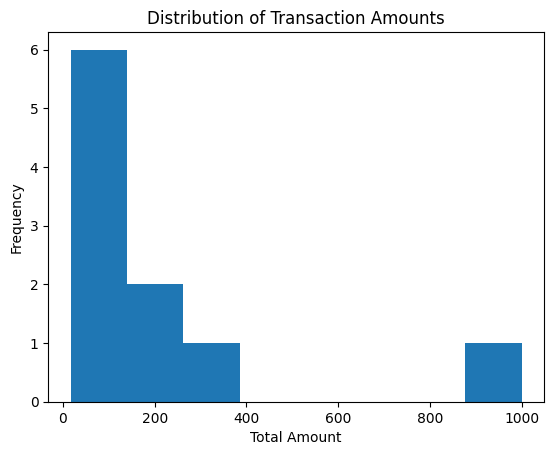

In [127]:
# Plot the distribution of transaction Total_Amount values.
retail["Total_Amount"].plot(
    kind="hist",
    bins=8,
    title="Distribution of Transaction Amounts"
)

plt.xlabel("Total Amount")
plt.show()

### 26.2 Plot grouped revenue

A grouped bar chart makes category totals easier to compare visually.

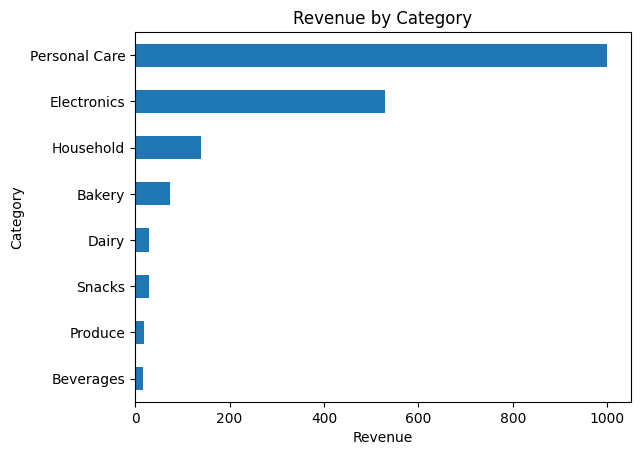

In [128]:
# Aggregate first, then visualize the category totals.
(
    retail.groupby("Category")["Total_Amount"]
    .sum()
    .sort_values()
    .plot(
        kind="barh",
        title="Revenue by Category"
    )
)

plt.xlabel("Revenue")
plt.show()

### 26.3 Plot a scatter relationship

A scatter plot places one numerical feature on each axis so we can inspect possible association and unusual observations.

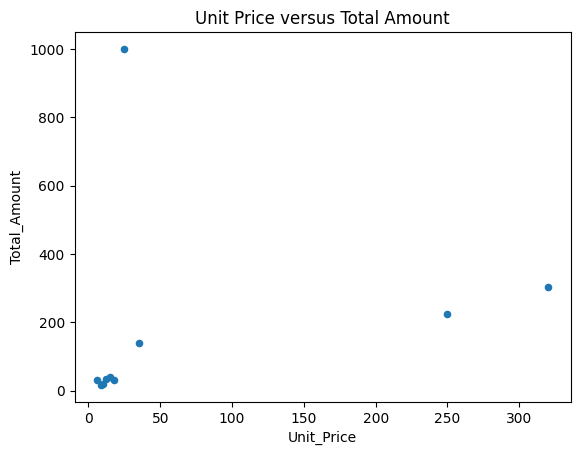

In [129]:
# Compare Unit_Price with final transaction Total_Amount.
retail.plot(
    kind="scatter",
    x="Unit_Price",
    y="Total_Amount",
    title="Unit Price versus Total Amount"
)

plt.show()

### 26.4 Plot Quantity as a box plot

A box plot visually emphasizes the median, quartiles, spread, and values beyond the usual whiskers. It complements our earlier IQR calculation.

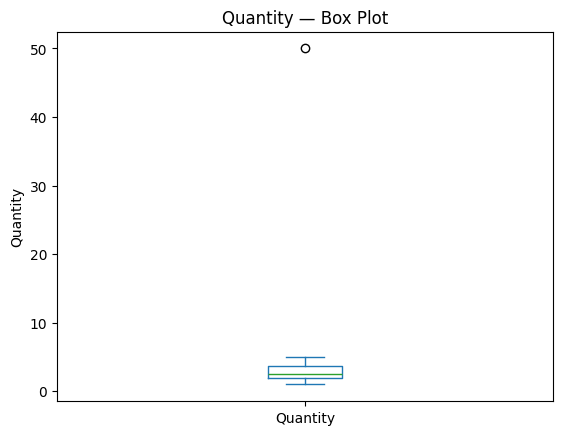

In [130]:
# Visualize the Quantity distribution and its unusually large value.
retail["Quantity"].plot(
    kind="box",
    title="Quantity — Box Plot"
)

plt.ylabel("Quantity")
plt.show()

## 27. Encoding categorical variables

Many machine-learning estimators require numerical inputs.

For **nominal** categories—labels with no natural order—one-hot encoding creates indicator columns rather than pretending that categories have numeric rank.

Pandas provides `get_dummies()` for this transformation.

We do not train a model here. We only prepare the table for a later machine-learning workflow.

### 27.1 Select nominal categorical variables

We first isolate the columns we intend to encode so the transformation is deliberate.

In [131]:
# Choose nominal features that do not have a meaningful numerical order.
categorical_features = retail[
    ["Gender", "City", "Category"]
]

categorical_features.head()

,Gender,City,Category
0,Female,Jeddah,Beverages
1,Male,Riyadh,Electronics
2,Female,Jeddah,Bakery
3,Male,Dammam,Household
4,Female,Makkah,Dairy


### 27.2 One-hot encode the selected variables

We use integer indicators for easy inspection. `drop_first=False` keeps every category because this is a teaching demonstration, not yet a specific regression design decision.

In [132]:
# Convert each observed category into 0/1 indicator columns.
encoded_features = pd.get_dummies(
    categorical_features,
    dtype=int
)

encoded_features.head()

,Gender_Female,Gender_Male,City_Dammam,City_Jeddah,City_Makkah,City_Riyadh,Category_Bakery,Category_Beverages,Category_Dairy,Category_Electronics,Category_Household,Category_Personal Care,Category_Produce,Category_Snacks
0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
1,0,1,0,0,0,1,0,0,0,1,0,0,0,0
2,1,0,0,1,0,0,1,0,0,0,0,0,0,0
3,0,1,1,0,0,0,0,0,0,0,1,0,0,0
4,1,0,0,0,1,0,0,0,1,0,0,0,0,0


### 27.3 Inspect the new encoded column names

Encoding can greatly increase the number of columns. Listing the names makes the transformation concrete.

In [133]:
# Display the feature names created by one-hot encoding.
encoded_features.columns.tolist()

['Gender_Female',
 'Gender_Male',
 'City_Dammam',
 'City_Jeddah',
 'City_Makkah',
 'City_Riyadh',
 'Category_Bakery',
 'Category_Beverages',
 'Category_Dairy',
 'Category_Electronics',
 'Category_Household',
 'Category_Personal Care',
 'Category_Produce',
 'Category_Snacks']

## 28. Prepare `X` and `y` for a later classification task

In supervised learning:

- `X` contains the **input features**.
- `y` contains the **target** we want to predict.

Our future example will predict whether a transaction was returned.

We keep preparation separate from model training so students understand that machine learning begins with a carefully designed table.

### 28.1 Choose numerical model features

We begin with a small set of interpretable numerical predictors. The target is deliberately excluded.

In [134]:
# Define the numerical features for a later classification example.
feature_columns = [
    "Customer_Age",
    "Quantity",
    "Unit_Price",
    "Discount_Percent",
    "Total_Amount"
]

feature_columns

['Customer_Age', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Amount']

### 28.2 Create the feature matrix `X`

`X` is two-dimensional because it may contain several predictor columns.

In [135]:
# Select the input features as a DataFrame.
X = retail[feature_columns]

X.head()

,Customer_Age,Quantity,Unit_Price,Discount_Percent,Total_Amount
0,22,2,8.5,0,17.0
1,35,1,250.0,10,225.0
2,28,3,12.0,5,34.2
3,45,4,35.0,0,140.0
4,31,2,18.0,15,30.6


### 28.3 Create the target vector `y`

`y` is one-dimensional because each observation has one target value.

In [136]:
# Use the binary return flag as the future prediction target.
y = retail["Returned_Flag"]

y.head()

0    0
1    1
2    0
3    0
4    0
Name: Returned_Flag, dtype: int64

### 28.4 Check feature and target shapes

The number of rows in `X` and `y` must match so every feature row has one target label.

In [137]:
# Confirm that X and y refer to the same number of observations.
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10, 5)
y shape: (10,)


### 28.5 Check for missing feature values

Many modeling workflows require explicit handling of missing features. We verify completeness before passing data onward.

In [138]:
# Count missing values in each future model feature.
X.isna().sum()

Customer_Age        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Amount        0
dtype: int64

## 29. CSV input and output

So far, our dataset was created inside the notebook. Real projects usually begin with external files.

The pandas I/O pattern is:

- `pd.read_csv(...)` → read a CSV file into a DataFrame.
- `df.to_csv(...)` → write a DataFrame to a CSV file.

We first create a local teaching CSV from our raw table so every following example is self-contained.

### 29.1 Save a raw teaching CSV

This file represents the kind of external dataset students would normally receive.

In [139]:
# Write the untouched raw dataset to the notebook's current working directory.
retail_raw.to_csv(
    "retail_training_raw.csv",
    index=False
)

print("Created: retail_training_raw.csv")

Created: retail_training_raw.csv


### 29.2 Read the CSV normally

The simplest call asks pandas to infer the schema from the file.

In [140]:
# Load the complete CSV using default type inference.
retail_from_csv = pd.read_csv(
    "retail_training_raw.csv"
)

retail_from_csv.head()

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
0,T001,22.0,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No
3,T004,45.0,Male,Dammam,Household,4,35.0,0,2026-06-03,No
4,T005,31.0,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No


### 29.3 Read only selected columns with `usecols`

Large files may contain many variables that are irrelevant to a task. Reading fewer columns can reduce memory usage and make analysis clearer.

In [141]:
# Load only the columns needed for a small sales analysis.
sales_subset = pd.read_csv(
    "retail_training_raw.csv",
    usecols=[
        "Transaction_ID",
        "Category",
        "Quantity",
        "Unit_Price"
    ]
)

sales_subset.head()

,Transaction_ID,Category,Quantity,Unit_Price
0,T001,Beverages,2,8.5
1,T002,Electronics,1,250.0
2,T003,Bakery,3,12.0
3,T004,Household,4,35.0
4,T005,Dairy,2,18.0


### 29.4 Recognize custom missing markers during import

CSV files often use text such as `Unknown`, `?`, or `N/A` to represent missing information. `na_values` lets us standardize such placeholders at read time.

In [142]:
# Treat the literal text "Unknown" as missing while reading the file.
retail_with_custom_na = pd.read_csv(
    "retail_training_raw.csv",
    na_values=["Unknown"]
)

retail_with_custom_na["Gender"].isna().sum()

np.int64(1)

### 29.5 Parse dates during import

Instead of reading a date as text and converting it later, `parse_dates` can request datetime parsing during import.

In [143]:
# Parse Purchase_Date immediately as a datetime column.
retail_with_dates = pd.read_csv(
    "retail_training_raw.csv",
    parse_dates=["Purchase_Date"]
)

retail_with_dates["Purchase_Date"].dtype

dtype('<M8[ns]')

### 29.6 Save the cleaned dataset

After preprocessing, exporting the result allows future analyses to reuse the same standardized data.

In [144]:
# Save the cleaned/transformed working table without writing the DataFrame index.
retail.to_csv(
    "retail_cleaned_example.csv",
    index=False
)

print("Created: retail_cleaned_example.csv")

Created: retail_cleaned_example.csv


# Teaching Extensions

The core workflow is now complete: we moved from raw data to a cleaned, transformed, summarized, and exportable table.

The following sections deepen pandas understanding without changing that core story.

## 30. Method chaining: read a workflow from left to right

Students often write many temporary variables. That is perfectly acceptable while learning.

Once each individual operation is understood, pandas methods can also be **chained** so that a transformation reads as one logical pipeline.

We should learn chaining **after** the individual methods—not before—because concise code is only useful when its logic is understood.

### 30.1 Build a small chained analysis

We will select high-value transactions, sort them, and keep only a few columns. The parentheses allow each method to appear on its own readable line.

In [145]:
# Create a compact analysis pipeline from already-understood operations.
high_value_view = (
    retail
    .loc[retail["Total_Amount"] >= 100]
    .sort_values("Total_Amount", ascending=False)
    .loc[:, ["Transaction_ID", "Category", "Total_Amount"]]
)

high_value_view

,Transaction_ID,Category,Total_Amount
8,T009,Personal Care,1000.0
5,T006,Electronics,304.0
1,T002,Electronics,225.0
3,T004,Household,140.0


### 30.2 Add a derived column with `assign()`

`assign()` is especially convenient inside a chain because it returns a new DataFrame with the added column.

In [146]:
# Add a rounded currency-style amount without modifying retail.
rounded_view = (
    retail
    .assign(Total_Amount_Rounded=retail["Total_Amount"].round(0))
    .loc[:, ["Transaction_ID", "Total_Amount", "Total_Amount_Rounded"]]
)

rounded_view.head()

,Transaction_ID,Total_Amount,Total_Amount_Rounded
0,T001,17.0,17.0
1,T002,225.0,225.0
2,T003,34.2,34.0
3,T004,140.0,140.0
4,T005,30.6,31.0


## 31. Safe assignment with `.loc`

A common pandas mistake is to select a subset and then try to modify it through chained indexing.

A safer teaching pattern is:

```python
df.loc[row_condition, "Column"] = value
```

This clearly identifies both the rows and the destination column in a single assignment operation.

### 31.1 Create a High_Value flag with `.loc`

We initialize the column, then update only rows that satisfy the condition. This is explicit and easy to audit.

In [147]:
# Start by labeling every transaction as not high value.
retail["High_Value"] = False

# Update only transactions with Total_Amount of at least 100.
retail.loc[
    retail["Total_Amount"] >= 100,
    "High_Value"
] = True

retail[["Transaction_ID", "Total_Amount", "High_Value"]].head()

,Transaction_ID,Total_Amount,High_Value
0,T001,17.0,False
1,T002,225.0,True
2,T003,34.2,False
3,T004,140.0,True
4,T005,30.6,False


## 32. Turn assumptions into validation checks

Data analysis contains many hidden assumptions:

- IDs should be unique.
- Percentages should lie in a valid range.
- quantities should be positive.
- a binary target should contain only expected labels.

Instead of merely believing these assumptions, we can test them.

`assert` is useful in teaching because a failed assumption stops execution immediately.

### 32.1 Validate unique transaction IDs

After duplicate removal, each Transaction_ID should appear only once.

In [148]:
# Stop with an error if transaction IDs are not unique.
assert retail["Transaction_ID"].is_unique

print("Validation passed: Transaction_ID is unique.")

Validation passed: Transaction_ID is unique.


### 32.2 Validate discount percentages

A percentage below 0 or above 100 would violate the meaning of this field.

In [149]:
# Verify that every discount is in the inclusive 0-100 range.
assert retail["Discount_Percent"].between(0, 100).all()

print("Validation passed: discounts are between 0 and 100.")

Validation passed: discounts are between 0 and 100.


### 32.3 Validate positive quantities

For this retail context, a transaction quantity should be greater than zero.

In [150]:
# Verify the domain rule for Quantity.
assert (retail["Quantity"] > 0).all()

print("Validation passed: all quantities are positive.")

Validation passed: all quantities are positive.


### 32.4 Validate binary target values

Our mapped target should contain only 0 and 1.

In [151]:
# Confirm that Returned_Flag contains no unexpected values.
assert set(retail["Returned_Flag"].dropna().unique()).issubset({0, 1})

print("Validation passed: Returned_Flag is binary.")

Validation passed: Returned_Flag is binary.


## 33. Daily summaries and rolling windows

The official pandas time-series tools extend beyond simple date extraction.

Once transactions have datetime values, we can aggregate them by day and calculate **rolling** summaries.

A rolling mean answers a question such as:

> What is the average daily revenue over the current day and the previous two observed days?

This introduces time-aware trend smoothing without requiring a forecasting model.

### 33.1 Calculate daily revenue

Several transactions may occur on one day, so we aggregate before calculating a rolling statistic.

In [152]:
# Sum all transaction revenue for each calendar date.
daily_revenue = (
    retail.groupby("Purchase_Date")["Total_Amount"]
    .sum()
    .sort_index()
)

daily_revenue

Purchase_Date
2026-06-01     242.0
2026-06-02      34.2
2026-06-03     170.6
2026-06-04     304.0
2026-06-05      50.0
2026-06-06    1000.0
2026-06-07      40.5
Name: Total_Amount, dtype: float64

### 33.2 Calculate a three-observation rolling mean

The rolling window moves through the ordered daily Series. `min_periods=1` allows the first days to have a value even before three observations exist.

In [153]:
# Smooth daily revenue using the current and previous two observed days.
rolling_revenue = daily_revenue.rolling(
    window=3,
    min_periods=1
).mean()

rolling_revenue

Purchase_Date
2026-06-01    242.000000
2026-06-02    138.100000
2026-06-03    148.933333
2026-06-04    169.600000
2026-06-05    174.866667
2026-06-06    451.333333
2026-06-07    363.500000
Name: Total_Amount, dtype: float64

## 34. Memory awareness

For our 10-row dataset, memory is not a problem.

But pandas is often used with hundreds of thousands or millions of rows. The official pandas scaling guidance emphasizes ideas such as:

- load only the columns we need,
- use efficient dtypes,
- process data in chunks when appropriate.

We introduce these ideas now so students understand that good pandas practice scales beyond toy examples.

### 34.1 Measure memory usage by column

`memory_usage(deep=True)` includes a deeper estimate for text-like columns.

In [154]:
# Estimate memory consumed by each column of the cleaned table.
retail.memory_usage(deep=True)

Index                      132
Transaction_ID             530
Customer_Age                90
Gender                     542
City                       550
Category                   573
Quantity                    80
Unit_Price                  80
Discount_Percent            80
Purchase_Date               80
Returned                   512
Gross_Amount                80
Discount_Amount             80
Total_Amount                80
Returned_Flag               80
Age_Group                  293
Amount_Group               236
Discount_Level             618
Purchase_Year               40
Purchase_Month              40
Purchase_Day_Name          561
Category_Average_Amount     80
Amount_vs_Category_Avg      80
High_Value                  10
dtype: int64

### 34.2 Compare string and categorical storage

Repeated labels can sometimes use less memory as categorical data. The benefit becomes much larger on large datasets with few unique categories.

In [155]:
# Create a temporary copy so we can compare storage without changing retail.
memory_demo = retail[["Category"]].copy()

string_memory = memory_demo.memory_usage(deep=True).sum()

memory_demo["Category"] = memory_demo["Category"].astype("category")
category_memory = memory_demo.memory_usage(deep=True).sum()

print("String-like storage:", string_memory, "bytes")
print("Categorical storage:", category_memory, "bytes")

String-like storage: 705 bytes
Categorical storage: 900 bytes


### 34.3 Read a CSV in chunks

Chunking lets us process a large file piece by piece instead of loading every row at once. Our file is tiny, but the mechanism is the same.

In [156]:
# Create an iterator that reads four rows at a time.
chunk_reader = pd.read_csv(
    "retail_training_raw.csv",
    chunksize=4
)

# Retrieve only the first chunk for demonstration.
first_chunk = next(chunk_reader)

first_chunk

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned
0,T001,22.0,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No
1,T002,35.0,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes
2,T003,28.0,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No
3,T004,45.0,Male,Dammam,Household,4,35.0,0,2026-06-03,No


## 35. Common pandas mistakes and how we reason around them

### Mistake 1 — confusing labels with positions
- `.loc` → labels / conditions
- `.iloc` → integer positions

### Mistake 2 — using Python `and` / `or` with Series
Use element-wise:
- `&` for AND
- `|` for OR
- parentheses around each comparison

### Mistake 3 — deleting outliers automatically
Flag first, investigate second, decide third.

### Mistake 4 — treating `"Unknown"` as automatically missing
Business placeholders are text until we explicitly standardize them.

### Mistake 5 — cleaning before inspecting
Every cleaning decision should respond to evidence found during inspection.

### Mistake 6 — overwriting raw data
Keep a raw source and modify a working copy.

### Mistake 7 — assuming a merge is correct
Use key checks, `validate=`, and optionally `indicator=True`.

### Mistake 8 — using loops for simple column arithmetic
Prefer vectorized pandas operations when the calculation naturally applies element by element.

# 36. Practice exercises

Try these **without looking at the solutions first**.

## Foundation
1. Display the first 4 rows of `retail`.
2. Display only `Transaction_ID`, `City`, and `Total_Amount`.
3. Select rows at integer positions 2 through 5.
4. Find all transactions from Jeddah.

## Filtering and sorting
5. Find transactions where `Quantity >= 3` and `Discount_Percent > 0`.
6. Find transactions whose Category is Bakery, Dairy, or Produce.
7. Display the three highest `Total_Amount` transactions.

## Cleaning and transformation
8. Confirm that `retail` contains no missing values.
9. Create a new column `Price_After_10pct_Reduction` equal to 90% of `Unit_Price`.
10. Create `Age_Band_2` with two groups: under 35 and 35 or older.

## Grouping and reshaping
11. Calculate total revenue by City.
12. Calculate average `Total_Amount` by Returned status.
13. Build a cross-tabulation of City versus Gender.
14. Build a pivot table of total revenue with City as rows and Returned as columns.

## Dates and text
15. Find transactions made on a Friday.
16. Find categories containing the letter sequence `"care"` ignoring case.

## Integration
17. Merge a new small loyalty table with `customers`.
18. Save only `Transaction_ID`, `Category`, and `Total_Amount` to a CSV named `retail_summary_export.csv`.

# 37. Exercise solutions

The solutions are intentionally separated into individual cells so each task can be checked independently.

### Solution 1 — first 4 rows

Use `head(n)` when the task is a top-of-table preview.

In [157]:
# Display exactly four rows from the beginning.
retail.head(4)

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned,Gross_Amount,Discount_Amount,Total_Amount,Returned_Flag,Age_Group,Amount_Group,Discount_Level,Purchase_Year,Purchase_Month,Purchase_Day_Name,Category_Average_Amount,Amount_vs_Category_Avg,High_Value
0,T001,22,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No,17.0,0.0,17.0,0,Under 30,Lower half,No discount,2026,6,Monday,17.00,0.00,False
1,T002,35,Male,Riyadh,Electronics,1,250.0,10,2026-06-01,Yes,250.0,25.0,225.0,1,30 to 39,Upper half,Small discount,2026,6,Monday,264.50,-39.50,True
2,T003,28,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No,36.0,1.8,34.2,0,Under 30,Lower half,Small discount,2026,6,Tuesday,37.35,-3.15,False
3,T004,45,Male,Dammam,Household,4,35.0,0,2026-06-03,No,140.0,0.0,140.0,0,40 and above,Upper half,No discount,2026,6,Wednesday,140.00,0.00,True


### Solution 2 — selected columns

Pass a list of column names to keep a DataFrame result.

In [158]:
# Keep only the three requested variables.
retail[["Transaction_ID", "City", "Total_Amount"]].head()

,Transaction_ID,City,Total_Amount
0,T001,Jeddah,17.0
1,T002,Riyadh,225.0
2,T003,Jeddah,34.2
3,T004,Dammam,140.0
4,T005,Makkah,30.6


### Solution 3 — positional rows

Positions 2 through 5 require a stop position of 6 because ordinary positional slicing excludes the stop.

In [159]:
# iloc uses Python-style half-open slicing: 2, 3, 4, 5.
retail.iloc[2:6]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned,Gross_Amount,Discount_Amount,Total_Amount,Returned_Flag,Age_Group,Amount_Group,Discount_Level,Purchase_Year,Purchase_Month,Purchase_Day_Name,Category_Average_Amount,Amount_vs_Category_Avg,High_Value
2,T003,28,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No,36.0,1.8,34.2,0,Under 30,Lower half,Small discount,2026,6,Tuesday,37.35,-3.15,False
3,T004,45,Male,Dammam,Household,4,35.0,0,2026-06-03,No,140.0,0.0,140.0,0,40 and above,Upper half,No discount,2026,6,Wednesday,140.00,0.00,True
4,T005,31,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No,36.0,5.4,30.6,0,30 to 39,Lower half,Large discount,2026,6,Wednesday,30.60,0.00,False
5,T006,52,Male,Jeddah,Electronics,1,320.0,5,2026-06-04,Yes,320.0,16.0,304.0,1,40 and above,Upper half,Small discount,2026,6,Thursday,264.50,39.50,True


### Solution 4 — Jeddah transactions

Create a Boolean comparison on City and use it to filter rows.

In [160]:
# Keep only rows where City equals Jeddah.
retail[retail["City"] == "Jeddah"]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned,Gross_Amount,Discount_Amount,Total_Amount,Returned_Flag,Age_Group,Amount_Group,Discount_Level,Purchase_Year,Purchase_Month,Purchase_Day_Name,Category_Average_Amount,Amount_vs_Category_Avg,High_Value
0,T001,22,Female,Jeddah,Beverages,2,8.5,0,2026-06-01,No,17.0,0.0,17.0,0,Under 30,Lower half,No discount,2026,6,Monday,17.00,0.00,False
2,T003,28,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No,36.0,1.8,34.2,0,Under 30,Lower half,Small discount,2026,6,Tuesday,37.35,-3.15,False
5,T006,52,Male,Jeddah,Electronics,1,320.0,5,2026-06-04,Yes,320.0,16.0,304.0,1,40 and above,Upper half,Small discount,2026,6,Thursday,264.50,39.50,True
8,T009,39,Male,Jeddah,Personal Care,50,25.0,20,2026-06-06,No,1250.0,250.0,1000.0,0,30 to 39,Upper half,Large discount,2026,6,Saturday,1000.00,0.00,True
9,T010,27,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No,45.0,4.5,40.5,0,Under 30,Upper half,Small discount,2026,6,Sunday,37.35,3.15,False


### Solution 5 — two numerical conditions

Each Series comparison needs parentheses before combining them with `&`.

In [161]:
# Require both a quantity of at least 3 and a positive discount.
retail[
    (retail["Quantity"] >= 3)
    & (retail["Discount_Percent"] > 0)
]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned,Gross_Amount,Discount_Amount,Total_Amount,Returned_Flag,Age_Group,Amount_Group,Discount_Level,Purchase_Year,Purchase_Month,Purchase_Day_Name,Category_Average_Amount,Amount_vs_Category_Avg,High_Value
2,T003,28,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No,36.0,1.8,34.2,0,Under 30,Lower half,Small discount,2026,6,Tuesday,37.35,-3.15,False
8,T009,39,Male,Jeddah,Personal Care,50,25.0,20,2026-06-06,No,1250.0,250.0,1000.0,0,30 to 39,Upper half,Large discount,2026,6,Saturday,1000.00,0.00,True
9,T010,27,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No,45.0,4.5,40.5,0,Under 30,Upper half,Small discount,2026,6,Sunday,37.35,3.15,False


### Solution 6 — several categories

Use `isin()` for membership in a list of allowed labels.

In [162]:
# Keep rows whose Category belongs to the requested set.
retail[
    retail["Category"].isin(
        ["Bakery", "Dairy", "Produce"]
    )
]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned,Gross_Amount,Discount_Amount,Total_Amount,Returned_Flag,Age_Group,Amount_Group,Discount_Level,Purchase_Year,Purchase_Month,Purchase_Day_Name,Category_Average_Amount,Amount_vs_Category_Avg,High_Value
2,T003,28,Female,Jeddah,Bakery,3,12.0,5,2026-06-02,No,36.0,1.8,34.2,0,Under 30,Lower half,Small discount,2026,6,Tuesday,37.35,-3.15,False
4,T005,31,Female,Makkah,Dairy,2,18.0,15,2026-06-03,No,36.0,5.4,30.6,0,30 to 39,Lower half,Large discount,2026,6,Wednesday,30.60,0.00,False
7,T008,31,Female,Makkah,Produce,2,10.0,0,2026-06-05,No,20.0,0.0,20.0,0,30 to 39,Lower half,No discount,2026,6,Friday,20.00,0.00,False
9,T010,27,Female,Jeddah,Bakery,3,15.0,10,2026-06-07,No,45.0,4.5,40.5,0,Under 30,Upper half,Small discount,2026,6,Sunday,37.35,3.15,False


### Solution 7 — top three transactions

`nlargest()` directly expresses a top-k numerical query.

In [163]:
# Retrieve the three largest Total_Amount observations.
retail.nlargest(3, "Total_Amount")[
    ["Transaction_ID", "Category", "Total_Amount"]
]

,Transaction_ID,Category,Total_Amount
8,T009,Personal Care,1000.0
5,T006,Electronics,304.0
1,T002,Electronics,225.0


### Solution 8 — missing-value verification

Sum the per-column missing counts to obtain one overall count.

In [164]:
# Confirm the total number of missing cells in the cleaned table.
print("Total missing cells:", retail.isna().sum().sum())

Total missing cells: 0


### Solution 9 — reduced price

Vectorized multiplication applies the same proportional transformation to the full column.

In [165]:
# Calculate 90% of Unit_Price without using a loop.
retail["Price_After_10pct_Reduction"] = (
    retail["Unit_Price"] * 0.90
)

retail[["Unit_Price", "Price_After_10pct_Reduction"]].head()

,Unit_Price,Price_After_10pct_Reduction
0,8.5,7.65
1,250.0,225.00
2,12.0,10.80
3,35.0,31.50
4,18.0,16.20


### Solution 10 — second age band

`pd.cut()` lets us supply our own business threshold.

In [166]:
# Divide ages at 35 using explicit bin boundaries.
retail["Age_Band_2"] = pd.cut(
    retail["Customer_Age"],
    bins=[0, 34, np.inf],
    labels=["Under 35", "35 or older"]
)

retail[["Customer_Age", "Age_Band_2"]].head()

,Customer_Age,Age_Band_2
0,22,Under 35
1,35,35 or older
2,28,Under 35
3,45,35 or older
4,31,Under 35


### Solution 11 — revenue by City

Group by City and sum the transaction amount within each group.

In [167]:
# Calculate and rank city revenue.
(
    retail.groupby("City")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

City
Jeddah    1395.7
Riyadh     255.0
Dammam     140.0
Makkah      50.6
Name: Total_Amount, dtype: float64

### Solution 12 — average by return status

The group key is Returned; the aggregated variable is Total_Amount.

In [168]:
# Compare mean transaction value for returned and non-returned transactions.
retail.groupby("Returned")["Total_Amount"].mean()

Returned
No     164.0375
Yes    264.5000
Name: Total_Amount, dtype: float64

### Solution 13 — City versus Gender

`crosstab()` counts combinations of categorical variables.

In [169]:
# Count Gender labels within each City.
pd.crosstab(
    retail["City"],
    retail["Gender"]
)

Gender,Female,Male
City,,
Dammam,0,1
Jeddah,3,2
Makkah,2,0
Riyadh,1,1


### Solution 14 — City by Returned pivot

A pivot table aggregates Total_Amount over two categorical dimensions.

In [170]:
# Sum transaction revenue for every City-Returned combination.
pd.pivot_table(
    retail,
    values="Total_Amount",
    index="City",
    columns="Returned",
    aggfunc="sum",
    fill_value=0
)

Returned,No,Yes
City,,
Dammam,140.0,0.0
Jeddah,1091.7,304.0
Makkah,50.6,0.0
Riyadh,30.0,225.0


### Solution 15 — Friday transactions

We already created Purchase_Day_Name, so the filter should reuse that feature rather than recomputing it.

In [171]:
# Keep transactions whose extracted weekday is Friday.
retail[
    retail["Purchase_Day_Name"] == "Friday"
][["Transaction_ID", "Purchase_Date", "Purchase_Day_Name"]]

,Transaction_ID,Purchase_Date,Purchase_Day_Name
6,T007,2026-06-05,Friday
7,T008,2026-06-05,Friday


### Solution 16 — text contains care

Use vectorized text matching and make the search case-insensitive.

In [172]:
# Search product-category labels for the requested text fragment.
retail[
    retail["Category"].str.contains(
        "care",
        case=False,
        na=False
    )
]

,Transaction_ID,Customer_Age,Gender,City,Category,Quantity,Unit_Price,Discount_Percent,Purchase_Date,Returned,Gross_Amount,Discount_Amount,Total_Amount,Returned_Flag,Age_Group,Amount_Group,Discount_Level,Purchase_Year,Purchase_Month,Purchase_Day_Name,Category_Average_Amount,Amount_vs_Category_Avg,High_Value,Price_After_10pct_Reduction,Age_Band_2
8,T009,39,Male,Jeddah,Personal Care,50,25.0,20,2026-06-06,No,1250.0,250.0,1000.0,0,30 to 39,Upper half,Large discount,2026,6,Saturday,1000.0,0.0,True,22.5,35 or older


### Solution 17 — loyalty merge

We create one row per customer in the lookup table, then validate the merge relationship.

In [173]:
# Create a small customer-level loyalty table.
loyalty = pd.DataFrame({
    "Customer_ID": ["C001", "C002", "C003"],
    "Loyalty_Level": ["Gold", "Silver", "Gold"]
})

# Attach loyalty information to the existing customer table.
customers.merge(
    loyalty,
    on="Customer_ID",
    how="left",
    validate="one_to_one"
)

,Customer_ID,Customer_Name,Customer_City,Loyalty_Level
0,C001,Ali,Jeddah,Gold
1,C002,Sara,Riyadh,Silver
2,C003,Omar,Dammam,Gold


### Solution 18 — export a summary CSV

Select only the requested columns before writing the file.

In [174]:
# Create the requested export table.
retail_summary_export = retail[
    ["Transaction_ID", "Category", "Total_Amount"]
]

# Save it without the DataFrame index.
retail_summary_export.to_csv(
    "retail_summary_export.csv",
    index=False
)

print("Created: retail_summary_export.csv")

Created: retail_summary_export.csv


# 38. Project application checklist

When we receive a new project dataset, we can reuse the notebook's logic in this order:

1. **Load** the source without immediately changing it.
2. **Preserve** a raw copy.
3. **Inspect** shape, columns, dtypes, `info()`, descriptive statistics, missing values, and duplicates.
4. **Understand** which variables are numerical, categorical, text, identifiers, or dates.
5. **Select/filter** only after understanding the schema.
6. **Standardize missing values** and justify the chosen strategy.
7. **Investigate duplicates** before dropping them.
8. **Normalize text** where inconsistent spelling/case/spacing exists.
9. **Convert dtypes** intentionally.
10. **Create features** only after their business meaning is clear.
11. **Investigate outliers** rather than deleting them automatically.
12. **Parse dates** before time-based analysis.
13. **Summarize categories** with frequencies and groupby.
14. **Reshape/combine** tables only with clear keys and relationship assumptions.
15. **Visualize** distributions and relationships.
16. **Validate** key assumptions.
17. **Prepare X and y** without target leakage.
18. **Export** the cleaned data and document what changed.

# 39. Final conceptual summary

Pandas is not just a collection of functions. It supports a disciplined reasoning workflow.

### The workflow we built

**Raw evidence**
→ `DataFrame`

**Understand**
→ `head`, `tail`, `sample`, `shape`, `dtypes`, `info`, `describe`

**Locate**
→ `[]`, `loc`, `iloc`, `at`, `iat`

**Ask row-level questions**
→ Boolean masks, `isin`, `between`, `query`

**Clean**
→ missing-data tools, `replace`, string methods, duplicate handling, dtype conversion

**Transform**
→ vectorized arithmetic, `map`, `cut`, `qcut`, datetime accessors

**Investigate**
→ descriptive statistics, IQR screening, plots

**Summarize**
→ `value_counts`, `groupby`, `agg`, `transform`, `crosstab`, `pivot_table`

**Reshape / integrate**
→ `pivot`, `melt`, `explode`, `merge`, `concat`

**Prepare for later modeling**
→ encoding, `X`, `y`, validation

**Persist**
→ `read_csv`, `to_csv`

The most important habit is not memorizing syntax. It is asking:

> **What do we know about the data now, and what evidence do we need before taking the next step?**

# 40. Official pandas references

Use the official documentation when a method or parameter needs verification:

- **User Guide:** https://pandas.pydata.org/docs/user_guide/
- **10 minutes to pandas:** https://pandas.pydata.org/docs/user_guide/10min.html
- **Indexing and selecting data:** https://pandas.pydata.org/docs/user_guide/indexing.html
- **Working with missing data:** https://pandas.pydata.org/docs/user_guide/missing_data.html
- **Working with text data:** https://pandas.pydata.org/docs/user_guide/text.html
- **GroupBy:** https://pandas.pydata.org/docs/user_guide/groupby.html
- **Merge / join / concatenate:** https://pandas.pydata.org/docs/user_guide/merging.html
- **Reshaping and pivot tables:** https://pandas.pydata.org/docs/user_guide/reshaping.html
- **Categorical data:** https://pandas.pydata.org/docs/user_guide/categorical.html
- **Time series / dates:** https://pandas.pydata.org/docs/user_guide/timeseries.html
- **Input/output tools:** https://pandas.pydata.org/docs/user_guide/io.html
- **Scaling to larger datasets:** https://pandas.pydata.org/docs/user_guide/scale.html

These references extend far beyond this notebook. We deliberately teach the most useful concepts in a gradual order before exposing advanced material.